# Project Fertility PSP

## 난임 환자 대상 임신 성공 여부 예측 프로젝트

본 프로젝트는 난임 환자 치료 데이터를 활용하여, 임신 성공 여부를 예측하는 분류 모델을 개발하는 과정이다.

분석은 데이터 탐색(EDA), 전처리 및 파생변수 생성, 모델링, 평가 순으로 진행한다. 

특히 본 프로젝트에서는 결측값을 단순 누락으로 보지 않고, 시술 프로세스와 연결된 신호로 해석하는 방향을 함께 고려한다.

## 00. 프로젝트 개요 및 분석 전략

본 프로젝트의 핵심 목표는 테스트 데이터에 대해 임신 성공 확률을 예측하는 것이다. 
평가지표는 ROC-AUC를 중심으로 하며, 예측 확률이 성공 사례와 실패 사례를 얼마나 잘 구분하는지에 중점을 둔다.

분석 전략은 다음과 같다.

- 결측값을 단순 제거하지 않고 시술 과정의 신호로 해석한다.
- 나이, 난자 수, 배아 수 등 주요 변수는 임상적 의미를 고려해 구간화한다.
- 범주형 변수와 조합 변수를 적극적으로 활용한다.
- CatBoost, LightGBM, XGBoost 등 트리 기반 모델을 비교한다.
- 최종 단계에서는 K-Fold OOF 검증과 앙상블을 통해 성능을 개선한다.

## 목차

01. 데이터 탐색(EDA)
- 데이터 로드 및 기본 구조 확인
- 타깃 분포 및 클래스 불균형 확인
- 결측치 현황 확인
- 시술 유형별 구조적 결측 확인
- 주요 변수별 임신 성공률 확인
- 나이, 난자, 배아 관련 구간화 기준 탐색

02. 데이터 전처리 및 Feature Engineering
- 기본 전처리 방향
- 임상 지식 기반 결측 유추
- 구조적 결측 flag 생성
- 구간화 변수 생성
- 조합 변수 및 비율 변수 생성
- 인코딩 및 데이터 분리

03. 모델링
- Baseline 모델
- CatBoost 모델
- LightGBM / XGBoost 모델
- K-Fold OOF 학습
- 앙상블 전략

04. 평가
- ROC-AUC 중심 평가
- 보조 지표 확인
- Feature Importance 및 Noise Pruning

05. 제출 및 리더보드 확인
- 제출 파일 생성
- 제출 파일 검증
- 리더보드 결과 기록


## 01. 데이터 탐색(EDA)

EDA 단계에서는 데이터의 기본 구조를 확인하고, 이후 전처리 및 파생변수 생성으로 연결될 수 있는 신호를 찾는다. 단순히 표와 그래프를 확인하는 것이 아니라, 모델이 학습할 수 있는 구조로 어떻게 변환할지까지 함께 고려한다.


### 01-1. 데이터 로드 및 기본 구조 확인

먼저 분석에 필요한 라이브러리와 시각화 테마를 설정하고, train/test/submission 파일을 불러온다.

이 단계에서 확인할 내용은 다음과 같다.

- train 데이터의 행/열 개수
- test 데이터의 행/열 개수
- 제출 파일 형식
- target 컬럼 존재 여부
- train/test 컬럼 차이


In [ ]:
# 라이브러리 및 시각화 기본 세팅

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from IPython.display import display

warnings.filterwarnings("ignore")

# 경로 설정
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
OUTPUT_DIR = PROJECT_DIR / "outputs" / "project_fertility_psp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 주요 컬럼 설정
TARGET = "임신 성공 여부"
ID_COL = "ID"
RANDOM_STATE = 42

# 한글 폰트 설정
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}

for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

# 모던한 다크 테마
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "figure.facecolor": "#111111",
    "axes.facecolor": "#111111",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#F2F2F2",
    "xtick.color": "#EAEAEA",
    "ytick.color": "#EAEAEA",
    "text.color": "#F2F2F2",
    "axes.titlecolor": "#FFFFFF",
    "grid.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
})

# seaborn 테마 적용 후 한글 폰트를 다시 고정
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

main_color = "#6EA8FE"
accent_color = "#FFB86B"
sub_color = "#8BE9A6"

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("font:", plt.rcParams["font.family"])


PROJECT_DIR: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트
OUTPUT_DIR: c:\Users\jkl83\OneDrive\Desktop\난임 환자 대상 임신 성공 여부 예측 AI 프로젝트\outputs\project_fertility_psp
font: ['Malgun Gothic']


In [2]:
# 데이터 로드

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("submission:", submission.shape)

assert TARGET in train.columns, f"target 컬럼을 찾을 수 없습니다: {TARGET}"
assert ID_COL in train.columns, f"ID 컬럼을 찾을 수 없습니다: {ID_COL}"
assert ID_COL in test.columns, f"test 데이터에서 ID 컬럼을 찾을 수 없습니다: {ID_COL}"

train: (256351, 69)
test: (90067, 68)
submission: (90067, 2)


In [3]:
# 데이터 미리보기

display(train.head())
display(test.head())
display(submission.head())

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,신선 배아 사용 여부,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일
0,TEST_00000,TRYBLT,만35-37세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN
1,TEST_00001,TRDQAZ,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN
2,TEST_00002,TRCMWS,만40-42세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN
3,TEST_00003,TRJXFG,만40-42세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN
4,TEST_00004,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,1.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,5.0,NaN


,ID,probability
0,TEST_00000,0.0
1,TEST_00001,0.0
2,TEST_00002,0.0
3,TEST_00003,0.0
4,TEST_00004,0.0


In [4]:
# train/test 컬럼 구조 확인

train_cols = set(train.columns)
test_cols = set(test.columns)

print("train columns:", train.shape[1])
print("test columns:", test.shape[1])
print("train에만 있는 컬럼:", sorted(train_cols - test_cols))
print("test에만 있는 컬럼:", sorted(test_cols - train_cols))

for i, col in enumerate(train.columns):
    print(i, col)


train columns: 69
test columns: 68
train에만 있는 컬럼: ['임신 성공 여부']
test에만 있는 컬럼: []
0 ID
1 시술 시기 코드
2 시술 당시 나이
3 임신 시도 또는 마지막 임신 경과 연수
4 시술 유형
5 특정 시술 유형
6 배란 자극 여부
7 배란 유도 유형
8 단일 배아 이식 여부
9 착상 전 유전 검사 사용 여부
10 착상 전 유전 진단 사용 여부
11 남성 주 불임 원인
12 남성 부 불임 원인
13 여성 주 불임 원인
14 여성 부 불임 원인
15 부부 주 불임 원인
16 부부 부 불임 원인
17 불명확 불임 원인
18 불임 원인 - 난관 질환
19 불임 원인 - 남성 요인
20 불임 원인 - 배란 장애
21 불임 원인 - 여성 요인
22 불임 원인 - 자궁경부 문제
23 불임 원인 - 자궁내막증
24 불임 원인 - 정자 농도
25 불임 원인 - 정자 면역학적 요인
26 불임 원인 - 정자 운동성
27 불임 원인 - 정자 형태
28 배아 생성 주요 이유
29 총 시술 횟수
30 클리닉 내 총 시술 횟수
31 IVF 시술 횟수
32 DI 시술 횟수
33 총 임신 횟수
34 IVF 임신 횟수
35 DI 임신 횟수
36 총 출산 횟수
37 IVF 출산 횟수
38 DI 출산 횟수
39 총 생성 배아 수
40 미세주입된 난자 수
41 미세주입에서 생성된 배아 수
42 이식된 배아 수
43 미세주입 배아 이식 수
44 저장된 배아 수
45 미세주입 후 저장된 배아 수
46 해동된 배아 수
47 해동 난자 수
48 수집된 신선 난자 수
49 저장된 신선 난자 수
50 혼합된 난자 수
51 파트너 정자와 혼합된 난자 수
52 기증자 정자와 혼합된 난자 수
53 난자 출처
54 정자 출처
55 난자 기증자 나이
56 정자 기증자 나이
57 동결 배아 사용 여부
58 신선 배아 사용 여부
59 기증 배아 사용 여부
60 대리모 여부
61 PGD 시술 여부
62 PGS 시술 여부
63 난자 채취 경과일
64 난자 해동 경과일

#### 해석 및 불균형 확인 필요성

train 데이터는 69개 컬럼, test 데이터는 68개 컬럼으로 구성되어 있다.  
train의 `임신 성공 여부`는 본 프로젝트의 예측 대상인 target 변수이다.

컬럼은 크게 다음과 같은 정보로 나눌 수 있다.

- 시술 기본 정보: `시술 시기 코드`, `시술 당시 나이`, `시술 유형`, `특정 시술 유형`
- 배란 및 유전검사 정보: `배란 자극 여부`, `배란 유도 유형`, `PGD/PGS 시술 여부`
- 불임 원인 정보: 남성/여성/부부 관련 불임 원인 변수
- 시술 이력 정보: 총 시술 횟수, IVF/DI 시술·임신·출산 횟수
- 난자/배아/정자 관련 정보: 생성 배아 수, 이식 배아 수, 난자 출처, 정자 출처 등
- 경과일 정보: 난자 채취, 난자 해동, 난자 혼합, 배아 이식, 배아 해동 경과일

다음 단계에서는 target 변수인 `임신 성공 여부`의 분포를 확인하여 클래스 불균형 여부를 살펴본다.

### 01-2. 타깃 분포 및 클래스 불균형 확인

타깃 변수인 `임신 성공 여부`의 0/1 분포를 확인한다. 본 프로젝트는 성공 사례가 실패 사례보다 적은 불균형 데이터이므로, Accuracy value보다 ROC-AUC 등 평가지표를 활용한다.

,count,ratio,ratio_percent
임신 성공 여부,,,
0,190123,0.741651,74.16511
1,66228,0.258349,25.83489


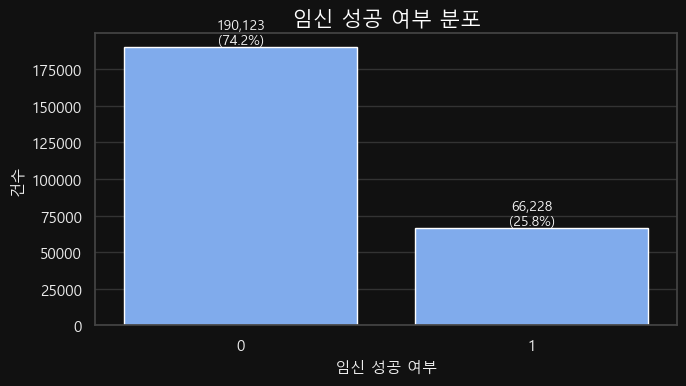

In [5]:
# 타깃 분포 확인

target_count = train[TARGET].value_counts().sort_index()
target_ratio = train[TARGET].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_count,
    "ratio": target_ratio,
    "ratio_percent": target_ratio * 100,
})

display(target_summary)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=target_count.index.astype(str), y=target_count.values, color=main_color)
ax.set_title("임신 성공 여부 분포")
ax.set_xlabel("임신 성공 여부")
ax.set_ylabel("건수")

for i, value in enumerate(target_count.values):
    pct = target_ratio.iloc[i] * 100
    ax.text(i, value, f"{value:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


#### 01-2. 결과 해석

- 74:26 비율로 성공(1)과 실패(0)의 비율 차이가 존재한다.
- 이 데이터는 클래스 불균형 문제를 포함하므로 Accuracy만으로 성능을 판단하지 않는다.
- 이후 모델 평가는 ROC-AUC를 핵심 지표로 사용하고, LogLoss, Recall, F1-score 등을 보조 지표로 확인한다.

* 참고: 성공과 실패를 얼마나 잘 구분하는지 평가하는 `ROC-AUC`를 핵심 지표로 사용한다. 또한 추론의 품질을 확인하기 위해 `LogLoss`, 재현율을 보기 위해 `Recall`과 `F1-score`도 함께 참고한다.

### 01-3. 결측치 현황 확인

전체 변수의 결측치를 확인한다. 결측률이 높은 변수를 무조건 제거하기보다, 결측이 발생한 이유가 시술 프로세스와 관련되어 있는지 확인한다.

,missing_count,missing_rate,missing_rate_percent
난자 해동 경과일,254915,0.994398,99.439831
PGS 시술 여부,254422,0.992475,99.247516
PGD 시술 여부,254172,0.991500,99.149994
착상 전 유전 검사 사용 여부,253633,0.989397,98.939735
임신 시도 또는 마지막 임신 경과 연수,246981,0.963449,96.344855
배아 해동 경과일,215982,0.842525,84.252451
난자 채취 경과일,57488,0.224255,22.425503
난자 혼합 경과일,53735,0.209615,20.961494
배아 이식 경과일,43566,0.169947,16.994667
미세주입 후 저장된 배아 수,6291,0.024541,2.454057


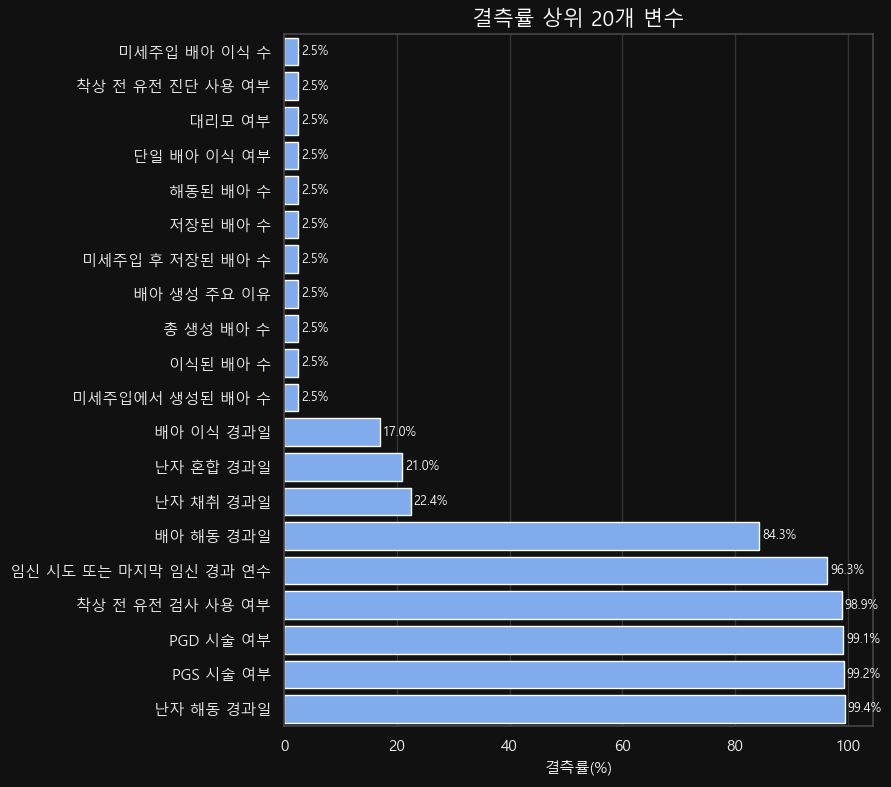

In [ ]:
# 결측치 현황 확인

missing = (
    train.isna().sum()
    .to_frame("missing_count")
    .assign(
        missing_rate=lambda x: x["missing_count"] / len(train),
        missing_rate_percent=lambda x: x["missing_rate"] * 100,
    )
    .sort_values("missing_count", ascending=False)
)

display(missing.head(30))

plt.figure(figsize=(9, 8))
plot_df = missing.head(20).sort_values("missing_rate_percent")
ax = sns.barplot(data=plot_df, x="missing_rate_percent", y=plot_df.index, color=main_color)
ax.set_title("결측률 상위 20개 변수") # 전체를 보여주면 너무 많아서 상위 20개만 시각화(EDA)
ax.set_xlabel("결측률(%)")
ax.set_ylabel("")

for i, value in enumerate(plot_df["missing_rate_percent"]):
    ax.text(value + 0.5, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


#### 01-3. 결과 해석

전체 결측치 현황을 확인한 결과, 일부 변수에서 매우 높은 결측률이 나타났다.

`난자 해동 경과일`, `PGS 시술 여부`, `PGD 시술 여부`, `착상 전 유전 검사 사용 여부`, `임신 시도 또는 마지막 임신 경과 연수`는 결측률이 약 96~99% 이상으로 매우 높다.  
이러한 변수들은 단순히 값이 누락되었다기보다, 특정 시술 또는 검사 자체가 대부분의 환자에게 수행되지 않았을 가능성이 있다.

또한 `배아 해동 경과일` 역시 결측률이 약 84.3%로 높게 나타났다.  
이는 모든 환자가 동결 배아 해동 과정을 거치는 것이 아니기 때문에 발생한 구조적 결측일 수 있다.

특히 여러 배아·난자 관련 변수에서 결측치 수가 동일하게 6,291건(2.5%)이다.
이는 특정 환자군 또는 특정 시술 유형에서 배아 생성, 배아 이식, 난자 채취 등의 과정이 존재하지 않았기 때문에 발생한 결측일 가능성이 있다.
따라서 결측률이 높다는 이유만으로 변수를 바로 삭제하기보다는, 결측이 발생한 원인을 시술 프로세스 관점에서 해석할 필요가 있다.

이후 전처리 단계에서는 다음 전략을 고려한다.

- 결측 자체를 의미 있는 정보로 보고 missing flag 변수를 생성한다. *핵심*
- 시술 유형별 결측 패턴을 확인하여 구조적 결측 여부를 판단한다.
- 트리 기반 모델에서는 일부 NaN을 그대로 유지하는 전략도 검토한다.
- 선형 모델이나 MLP 계열 모델에서는 결측 대체와 missing flag를 함께 사용한다.

다음 단계에서는 `시술 유형`별 결측 패턴을 확인하여, 결측값이 특정 시술 프로세스와 연결되어 있는지 살펴본다.

### 01-4. 시술 유형별 구조적 결측 확인

DI와 IVF는 시술 프로세스가 다르기 때문에 결측 패턴도 다를 수 있다. 특히 배아 관련 변수의 결측은 단순 누락이 아니라 해당 시술에서 해당 과정이 존재하지 않는다는 의미일 수 있다.


In [ ]:
# 시술 유형별 결측 패턴 확인

treatment_col = "시술 유형"

if treatment_col in train.columns:
    treatment_counts = train[treatment_col].value_counts(dropna=False)
    display(treatment_counts.to_frame("count"))

    missing_by_treatment = (
        train.groupby(treatment_col, dropna=False)
        .apply(lambda x: x.isna().mean())
        .T
    )

    missing_by_treatment["max_missing_rate"] = missing_by_treatment.max(axis=1)
    missing_by_treatment = missing_by_treatment.sort_values("max_missing_rate", ascending=False)

    display(missing_by_treatment.head(30))
else:
    print(f"{treatment_col} 컬럼이 없습니다.")


,count
시술 유형,
IVF,250060
DI,6291


시술 유형,DI,IVF,max_missing_rate
배아 생성 주요 이유,1.000000,0.000000,1.000000
착상 전 유전 진단 사용 여부,1.000000,0.000000,1.000000
착상 전 유전 검사 사용 여부,1.000000,0.989131,1.000000
단일 배아 이식 여부,1.000000,0.000000,1.000000
대리모 여부,1.000000,0.000000,1.000000
기증 배아 사용 여부,1.000000,0.000000,1.000000
기증자 정자와 혼합된 난자 수,1.000000,0.000000,1.000000
파트너 정자와 혼합된 난자 수,1.000000,0.000000,1.000000
수집된 신선 난자 수,1.000000,0.000000,1.000000
해동 난자 수,1.000000,0.000000,1.000000


#### 01-4. 결과 해석

시술 유형별 결측 패턴을 확인한 결과, DI와 IVF 사이에 매우 뚜렷한 차이가 나타났다.

DI 시술에서는 `배아 생성 주요 이유`, `단일 배아 이식 여부`, `총 생성 배아 수`, `이식된 배아 수`, `미세주입된 난자 수`, `해동된 배아 수`, `신선/동결 배아 사용 여부` 등 배아·난자 관련 변수들이 100% 결측으로 나타났다.

반면 IVF 시술에서는 동일한 변수들의 결측률이 대부분 0%에 가깝다.  
이는 DI 시술에서 해당 정보가 단순히 누락된 것이 아니라, 시술 프로세스상 배아 생성·배아 이식·난자 채취 과정이 존재하지 않기 때문에 발생한 구조적 결측으로 해석할 수 있다.

즉, 결측값 자체가 “해당 시술 과정이 수행되지 않았다”는 중요한 정보를 담고 있다.  
따라서 이러한 변수들은 단순 삭제하거나 0으로 일괄 대체하기보다, 결측 여부를 feature로 활용하는 전략이 필요하다.

특히 다음과 같은 전처리 방향을 고려할 수 있다.

- DI 여부를 별도 feature로 명시한다.
- 배아·난자 관련 변수의 결측 여부를 missing flag로 생성한다.
- 트리 기반 모델에서는 구조적 NaN을 그대로 유지하거나, 결측 flag와 함께 사용한다.
- 선형 모델 또는 MLP 계열 모델에서는 중앙값/특정값 대체와 missing flag를 함께 사용한다.
- IVF와 DI의 시술 프로세스가 다르므로, 유형별 모델링 또는 시술 유형별 파생변수를 고려한다.

### 01-5. 주요 변수별 임신 성공률 확인

앞서 확인한 결측 패턴을 바탕으로, 주요 범주형 변수별 임신 성공률을 확인한다.

이 단계에서는 단순히 성공률이 높은 변수를 찾는 것이 아니라, 이후 파생변수 생성과 모델링에 활용할 수 있는 후보 변수를 선별하는 것을 목표로 한다.

In [9]:
# 주요 범주형 변수별 성공률 확인 함수
def success_rate_by_col(df, col, min_count=0):
    result = (
        df.groupby(col, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"mean": "success_rate"})
        .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
        .sort_values("success_rate_percent", ascending=False)
    )

    if min_count > 0:
        result = result[result["count"] >= min_count]

    return result


key_cat_cols = [
    "시술 유형",
    "시술 당시 나이",
    "특정 시술 유형",
    "배란 자극 여부",
    "배란 유도 유형",
    "배아 생성 주요 이유",
    "난자 출처",
    "정자 출처",
    "동결 배아 사용 여부",
    "신선 배아 사용 여부",
]

for col in key_cat_cols:
    if col in train.columns:
        print("\n" + "=" * 80)
        print(col)
        display(success_rate_by_col(train, col).head(20))


시술 유형


,count,success_rate,success_rate_percent
시술 유형,,,
IVF,250060,0.261605,26.160521
DI,6291,0.128914,12.891432



시술 당시 나이


,count,success_rate,success_rate_percent
시술 당시 나이,,,
만18-34세,102476,0.322622,32.262188
만35-37세,57780,0.278401,27.840083
만38-39세,39247,0.217138,21.713762
만45-50세,6918,0.167679,16.767852
만40-42세,37348,0.159393,15.939274
만43-44세,12253,0.118012,11.801192
알 수 없음,329,0.000000,0.000000



특정 시술 유형


...

,count,success_rate,success_rate_percent
정자 출처,,,
배우자 제공,229199,0.260167,26.016693
기증 제공,27016,0.243744,24.374445
미할당,122,0.106557,10.655738
배우자 및 기증 제공,14,0.000000,0.000000



동결 배아 사용 여부


,count,success_rate,success_rate_percent
동결 배아 사용 여부,,,
0.0,209934,0.267760,26.776034
1.0,40126,0.229402,22.940238
NaN,6291,0.128914,12.891432



신선 배아 사용 여부


,count,success_rate,success_rate_percent
신선 배아 사용 여부,,,
1.0,210136,0.267689,26.768854
0.0,39924,0.229586,22.958621
NaN,6291,0.128914,12.891432


#### 01-5. 결과 해석

주요 범주형 변수별 임신 성공률을 확인한 결과, 여러 변수에서 target과 뚜렷한 관계가 관찰되었다.

먼저 `시술 유형`에서는 IVF의 임신 성공률이 약 26.2%, DI의 임신 성공률이 약 12.9%로 나타났다.  
이는 IVF와 DI가 서로 다른 시술 프로세스를 가지며, 성공률과 결측 패턴 모두에서 차이가 크다는 것을 의미한다. 따라서 이후 모델링에서는 `시술 유형`을 주요 변수로 활용하고, DI에서 발생하는 구조적 결측을 별도로 고려할 필요가 있다.

`시술 당시 나이`에서는 나이가 증가할수록 전반적으로 임신 성공률이 낮아지는 경향이 확인되었다(관련 논문 추가 #1, #2. 난임과 나이의 인과관계).  
특히 만18-34세의 성공률은 약 32.3%인 반면, 만38-39세는 약 21.7%, 만40-42세는 약 15.9%, 만43-44세는 약 11.8%로 감소한다.  
이는 나이가 임신 성공 여부에 중요한 영향을 미치는 변수임을 보여주며, 이후 나이 구간화 또는 순서형 인코딩을 적용할 수 있다.

`특정 시술 유형`에서는 BLASTOCYST가 포함된 시술 유형의 성공률이 상대적으로 높게 나타났다(시술 유형에 따른 인사이트 #3).  
예를 들어 `IVF / BLASTOCYST`는 약 36.6%, `ICSI / BLASTOCYST`는 약 35.7%의 성공률을 보인다.  
반면 IUI는 약 12.9%로 낮게 나타나며, 이는 DI 계열 시술의 낮은 성공률과도 연결된다. 
따라서 `BLASTOCYST 포함 여부`, `ICSI 포함 여부`, `IVF 포함 여부`, `IUI 여부`와 같은 토큰 기반 파생변수를 생성할 수 있다.

`배아 생성 주요 이유`에서는 `기증용, 현재 시술용`의 성공률이 약 38.0%로 가장 높게 나타났다.  
반면 `배아 저장용`, `기증용`, `난자 저장용` 등 현재 시술 목적이 아닌 항목은 성공률이 거의 0%에 가깝다.  
따라서 `현재 시술용 여부`, `저장용 여부`, `기증용 여부`와 같은 파생변수 생성이 유효할 수 있다.

`난자 출처`에서는 기증 제공의 성공률이 약 31.5%, 본인 제공의 성공률이 약 25.8%로 나타났다.  
이는 기증 난자를 사용하는 경우 환자 본인의 나이보다 난자 자체의 생물학적 조건이 더 중요할 수 있음을 시사한다.  
따라서 이후 `나이 × 난자 출처` 조합 변수 또는 기증 난자 여부 변수를 고려할 필요가 있다.

`정자 출처`는 난자 출처에 비해 성공률 차이가 크지 않지만, 미할당 또는 배우자 및 기증 제공과 같이 표본 수가 작은 범주는 해석에 주의가 필요하다.

`동결 배아 사용 여부`와 `신선 배아 사용 여부`에서는 신선 배아 사용 또는 동결 배아 미사용 그룹의 성공률이 상대적으로 높게 나타났다.  
다만 이 변수들은 시술 프로세스, 배아 이식 여부, 배아 생성 주요 이유와 함께 해석해야 하므로 단독 효과만으로 결론을 내리기보다는 조합 변수로 활용하는 것이 적절하다.
종합하면, 이후 Feature Engineering에서 우선적으로 고려할 변수는 다음과 같다.

- `시술 유형`
- `시술 당시 나이`
- `특정 시술 유형`
- `배아 생성 주요 이유`
- `난자 출처`
- `동결 배아 사용 여부`
- `신선 배아 사용 여부`
- `나이 × 난자 출처`
- `시술 유형 × 특정 시술 유형` *7개 변수, 2개 co-변수 추가 (69+9)*

다음 단계에서는 나이, 난자 수, 배아 수처럼 임상적 의미가 있는 수치형/순서형 변수의 구간화 기준을 탐색한다.

### 01-6. 나이·난자·배아 관련 구간화 기준 탐색

나이, 난자 수, 배아 수는 임신 성공 여부와 직접적인 관련이 있을 가능성이 높은 변수이다.

이 단계에서는 값이 증가할수록 성공률이 단순히 선형적으로 변하는지, 또는 특정 구간에서 급격한 변화나 정체 구간이 나타나는지 확인한다.

이를 바탕으로 이후 전처리 단계에서 임상적 의미를 반영한 구간화 변수를 생성한다.

,시술 당시 나이,count,success_rate,success_rate_percent
0,만18-34세,102476,0.322622,32.262188
1,만35-37세,57780,0.278401,27.840083
2,만38-39세,39247,0.217138,21.713762
4,만40-42세,37348,0.159393,15.939274
5,만43-44세,12253,0.118012,11.801192
3,만45-50세,6918,0.167679,16.767852
6,알 수 없음,329,0.000000,0.000000


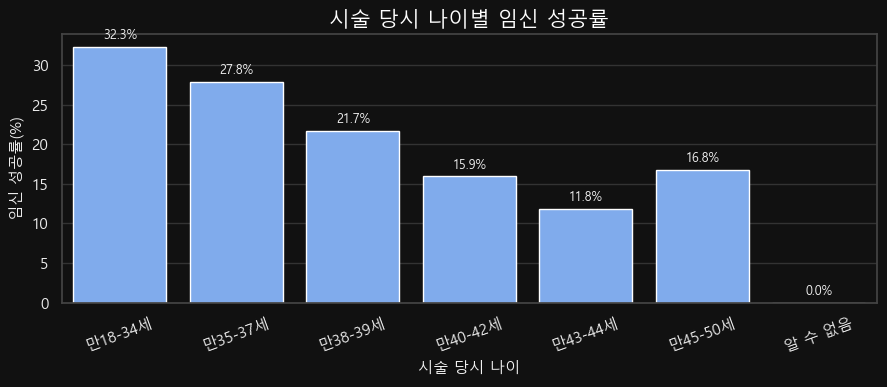

In [10]:
# 나이 구간별 성공률 확인: 이거 범주형인데 정렬해서 보면 다를듯
age_order = [
    "만18-34세",
    "만35-37세",
    "만38-39세",
    "만40-42세",
    "만43-44세",
    "만45-50세",
    "알 수 없음"
]

age_success = success_rate_by_col(train, "시술 당시 나이").reset_index()
age_success["시술 당시 나이"] = pd.Categorical(
    age_success["시술 당시 나이"],
    categories=age_order,
    ordered=True
)
age_success = age_success.sort_values("시술 당시 나이")

display(age_success)

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=age_success,
    x="시술 당시 나이",
    y="success_rate_percent",
    color=main_color
)

ax.set_title("시술 당시 나이별 임신 성공률")
ax.set_xlabel("시술 당시 나이")
ax.set_ylabel("임신 성공률(%)")
plt.xticks(rotation=20)

for i, row in age_success.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["success_rate_percent"] + 0.6,
        f'{row["success_rate_percent"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


수집된 신선 난자 수


,수집된 신선 난자 수_구간,count,success_rate,success_rate_percent
0,0개,53845,0.240487,24.048658
1,1-5개,40960,0.148730,14.873047
2,6-10개,64733,0.267777,26.777687
3,11개 이상,90522,0.320828,32.082809
4,NaN,6291,0.128914,12.891432


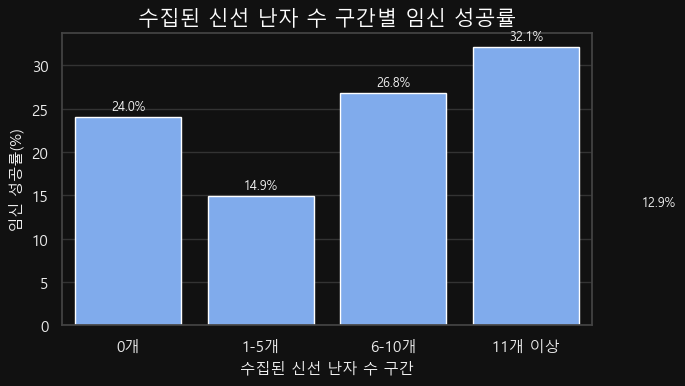


혼합된 난자 수


,혼합된 난자 수_구간,count,success_rate,success_rate_percent
0,0개,46650,0.196227,19.622722
1,1-5개,55563,0.176682,17.668232
2,6-10개,74683,0.296118,29.611826
3,11개 이상,73164,0.332554,33.255426
4,NaN,6291,0.128914,12.891432


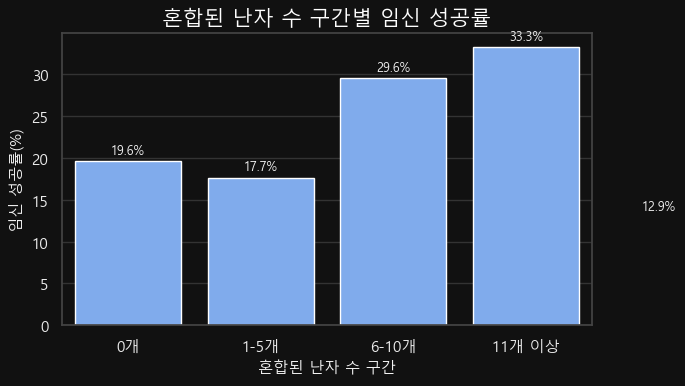


해동 난자 수


,해동 난자 수_구간,count,success_rate,success_rate_percent
0,0개,248615,0.261835,26.183456
1,1-5개,393,0.109415,10.941476
2,6-10개,729,0.252401,25.240055
3,11개 이상,323,0.291022,29.102167
4,NaN,6291,0.128914,12.891432


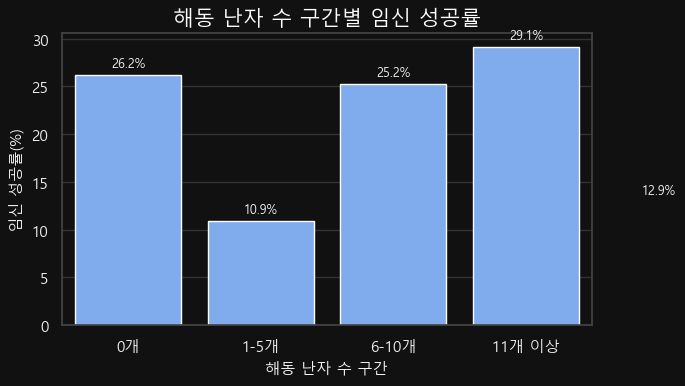

In [ ]:
# 난자 수 구간별 성공률 확인
def make_count_bin(s):
    return pd.cut(
        s,
        bins=[-1, 0, 5, 10, np.inf],
        labels=["0개", "1-5개", "6-10개", "11개 이상"]
    )

oocyte_cols = [
    "수집된 신선 난자 수",
    "혼합된 난자 수",
    "해동 난자 수"
]

for col in oocyte_cols:
    if col in train.columns:
        temp = train[[col, TARGET]].copy()
        temp[f"{col}_구간"] = make_count_bin(temp[col])

        result = (
            temp.groupby(f"{col}_구간", dropna=False)[TARGET]
            .agg(["count", "mean"])
            .rename(columns={"mean": "success_rate"})
            .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
            .reset_index()
        )

        print("\n" + "=" * 80)
        print(col)
        display(result)

        plt.figure(figsize=(7, 4))
        ax = sns.barplot(
            data=result,
            x=f"{col}_구간",
            y="success_rate_percent",
            color=main_color
        )

        ax.set_title(f"{col} 구간별 임신 성공률")
        ax.set_xlabel(f"{col} 구간")
        ax.set_ylabel("임신 성공률(%)")

        for i, row in result.iterrows():
            ax.text(
                i,
                row["success_rate_percent"] + 0.5,
                f'{row["success_rate_percent"]:.1f}%',
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()


총 생성 배아 수


,총 생성 배아 수_구간,count,success_rate,success_rate_percent
0,0개,53349,0.171868,17.186826
1,1-2개,34413,0.142388,14.238805
2,3-5개,62974,0.274637,27.463715
3,6개 이상,99324,0.342848,34.284765
4,NaN,6291,0.128914,12.891432


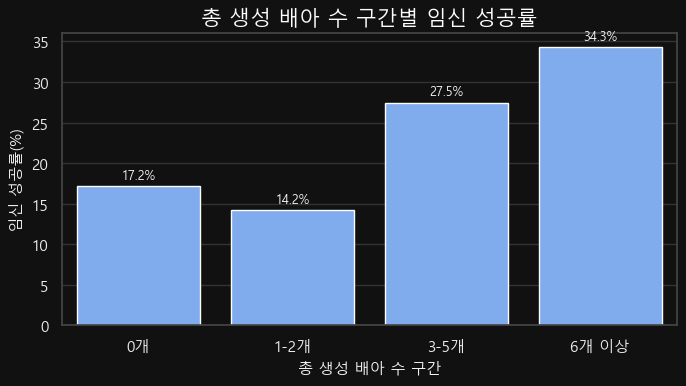


이식된 배아 수


,이식된 배아 수_구간,count,success_rate,success_rate_percent
0,0개,36544,0.000821,0.082093
1,1-2개,204636,0.312218,31.221779
2,3-5개,8880,0.168468,16.846847
3,6개 이상,0,NaN,NaN
4,NaN,6291,0.128914,12.891432


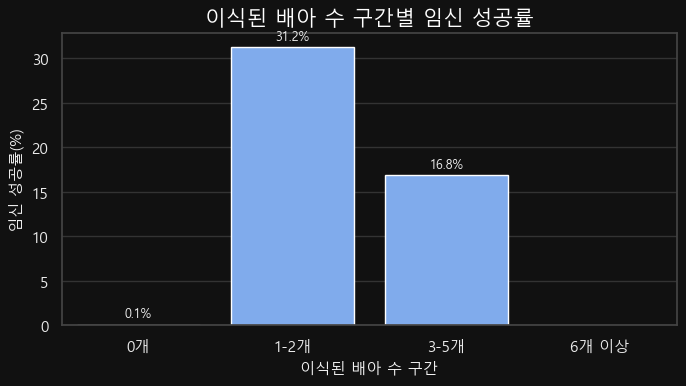


저장된 배아 수


,저장된 배아 수_구간,count,success_rate,success_rate_percent
0,0개,166866,0.222130,22.213033
1,1-2개,40245,0.357759,35.775873
2,3-5개,28731,0.362431,36.243082
3,6개 이상,14218,0.248980,24.898017
4,NaN,6291,0.128914,12.891432


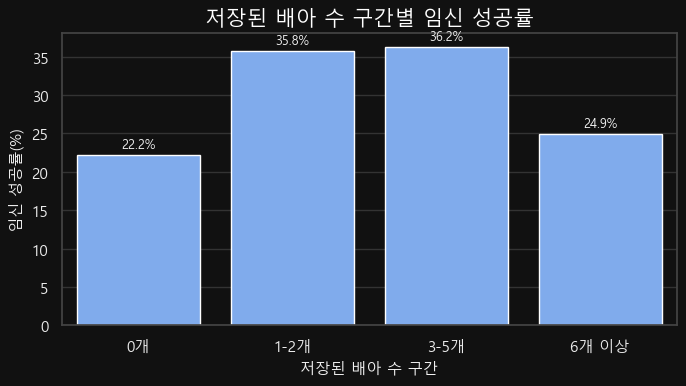

In [ ]:
# 배아 수 구간별 성공률 확인
def make_embryo_bin(s):
    return pd.cut(
        s,
        bins=[-0.1, 0, 2, 5, np.inf],
        labels=["0개", "1-2개", "3-5개", "6개 이상"],
        include_lowest=True
    )

embryo_cols = [
    "총 생성 배아 수",
    "이식된 배아 수",
    "저장된 배아 수"
]

for col in embryo_cols:
    if col in train.columns:
        temp = train[[col, TARGET]].copy()

        temp[f"{col}_구간"] = make_embryo_bin(temp[col])

        result = (
            temp.groupby(f"{col}_구간", dropna=False, observed=False)[TARGET]
            .agg(["count", "mean"])
            .rename(columns={"mean": "success_rate"})
            .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
            .reset_index()
        )

        # 표에는 결측 그룹도 확인
        display_result = result.copy()

        # 그래프에는 원값이 결측이 아닌 행만 사용
        plot_temp = temp[temp[col].notna()].copy()

        plot_result = (
            plot_temp.groupby(f"{col}_구간", observed=False)[TARGET]
            .agg(["count", "mean"])
            .rename(columns={"mean": "success_rate"})
            .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
            .reset_index()
        )

        print("\n" + "=" * 80)
        print(col)
        display(display_result)

        plt.figure(figsize=(7, 4))
        ax = sns.barplot(
            data=plot_result,
            x=f"{col}_구간",
            y="success_rate_percent",
            color=main_color
        )

        ax.set_title(f"{col} 구간별 임신 성공률")
        ax.set_xlabel(f"{col} 구간")
        ax.set_ylabel("임신 성공률(%)")

        for i, row in plot_result.reset_index(drop=True).iterrows():
            ax.text(
                i,
                row["success_rate_percent"] + 0.5,
                f'{row["success_rate_percent"]:.1f}%',
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show() # NaN 값이 자꾸 6이상에 달라붙는데 해결 필요

### 01-6. 결과 해석

나이, 난자 수, 배아 수 관련 변수의 구간별 임신 성공률을 확인한 결과, 여러 변수에서 임상적으로 해석 가능한 구간 패턴이 나타났다.

먼저 `시술 당시 나이`에서는 나이가 증가할수록 전반적으로 임신 성공률이 감소하는 경향이 확인되었다. (#1, #2 참고문헌 확인)
만18-34세의 성공률은 약 32.3%, 만35-37세는 약 27.8%, 만38-39세는 약 21.7%로 하락한다.  
특히 만35-37세에서 만38-39세 구간으로 넘어갈 때 성공률이 크게 낮아져, 38세 전후를 중요한 구간 기준으로 고려할 수 있다.  
다만 만45-50세의 성공률이 만43-44세보다 높게 나타나므로, 이 구간은 난자 출처나 기증 난자 사용 여부와 함께 추가 확인이 필요하다.

난자 수 관련 변수에서는 단순히 0개에서 1-5개로 증가한다고 성공률이 바로 높아지는 패턴은 아니었다.  
`수집된 신선 난자 수`와 `혼합된 난자 수` 모두 6-10개 구간부터 성공률이 뚜렷하게 상승하고, 11개 이상 구간에서 가장 높은 성공률을 보였다.  
이는 난자 수가 일정 수준 이상 확보될 때 성공 가능성이 높아지는 경향을 시사한다.  
반면 `해동 난자 수`는 0개에 수렴하고, 1개 이상 구간의 표본 수가 상대적으로 작기 때문에 해석에 주의가 필요하다.

배아 수 관련 변수에서는 `총 생성 배아 수`가 3-5개 이상부터 성공률이 뚜렷하게 상승하고, 6개 이상 구간에서 가장 높은 성공률을 보였다.  
이는 생성된 배아 수가 일정 수준 이상 확보될수록 임신 성공 가능성이 높아지는 경향을 보여준다.

`이식된 배아 수`에서는 0개 구간의 성공률이 거의 0%에 가깝게 나타났다.  
이는 배아 이식이 이루어지지 않은 경우 임신 성공 가능성이 매우 낮다는 점을 보여주는 강한 신호이다.  
반면 1-2개 이식 구간은 약 31.2%의 성공률을 보이며, 3-5개 구간보다 높게 나타났다.  
따라서 이식된 배아 수는 단순히 많을수록 좋은 변수가 아니라, 적정 이식 수가 중요할 수 있다.

`저장된 배아 수`는 1-2개, 3-5개 구간에서 성공률이 약 35~36%로 높게 나타났고, 6개 이상에서는 오히려 낮아졌다.  
이는 저장 배아 수가 일정 수준 이상 많다고 해서 성공률이 계속 증가하지는 않으며, 상단 평탄화 또는 다른 시술 조건과의 조합 효과가 존재할 수 있음을 시사한다.
종합하면, 이후 Feature Engineering에서는 다음 구간화 변수를 우선 고려한다. (#3 참고자료-용어사전- 확인)

- 나이 구간: 38세 전후, 40세 이상, 43세 이상 여부
- 난자 수 구간: 0개, 1-5개, 6-10개, 11개 이상
- 총 생성 배아 수 구간: 0개, 1-2개, 3-5개, 6개 이상
- 이식된 배아 수 구간: 0개, 1-2개, 3개 이상
- 저장된 배아 수 구간: 0개, 1-2개, 3-5개, 6개 이상

또한 각 변수의 NaN 그룹은 대부분 DI 시술과 연결된 구조적 결측일 가능성이 있으므로, 구간화와 별도로 missing flag 변수로 활용하는 것이 적절하다.
다음 단계에서는 EDA 결과를 바탕으로, 임상 지식 기반 결측 유추와 구조적 결측 flag 생성 방향을 정리한다. *+5개*

#### 제언: 임상에서의 결측치 유추 파생변수 확인

앞선 EDA에서 일부 변수의 결측이 단순 누락이 아니라 시술 프로세스와 연결된 구조적 결측일 가능성을 확인하였다.

이번 단계에서는 임상적 의미를 바탕으로 결측값을 유추할 수 있는 후보 규칙을 탐색한다.

예를 들어 해동된 배아 수가 1개 이상이면 동결 배아 이식(FER) 과정이 있었을 가능성이 있고, 미세주입된 난자 수가 1개 이상이면 ICSI 관련 시술이 수행되었을 가능성이 있다. *3기 1위 자료확인*

이러한 규칙은 바로 확정적으로 적용하기보다, train 데이터에서 해당 조건의 표본 수와 성공률을 먼저 확인한 뒤 전처리 단계에서 적용 여부를 판단한다.

In [21]:
# 결측치 유추 파생변수 확인
def rule_summary(df, mask, rule_name):
    subset = df.loc[mask]

    return {
        "rule": rule_name,
        "count": len(subset),
        "success_rate": subset[TARGET].mean(),
        "success_rate_percent": subset[TARGET].mean() * 100
    }


proc = train["특정 시술 유형"].astype("string")
ovulation_type = train["배란 유도 유형"].astype("string")

unknown_proc = proc.isna() | proc.isin(["Unknown", "알 수 없음"])
unknown_ovulation_type = ovulation_type.isna() | ovulation_type.isin(["Unknown", "알 수 없음"])

thawed_embryo_ge1 = pd.to_numeric(train["해동된 배아 수"], errors="coerce").fillna(0) >= 1
micro_oocyte_ge1 = pd.to_numeric(train["미세주입된 난자 수"], errors="coerce").fillna(0) >= 1
ovulation_stim_zero = pd.to_numeric(train["배란 자극 여부"], errors="coerce").fillna(-1) == 0

candidate_rules = [
    rule_summary(
        train,
        thawed_embryo_ge1,
        "해동된 배아 수 1개 이상: FER 가능성"
    ),
    rule_summary(
        train,
        thawed_embryo_ge1 & unknown_proc,
        "특정 시술 유형 Unknown + 해동된 배아 수 1개 이상: FER 유추 후보"
    ),
    rule_summary(
        train,
        micro_oocyte_ge1,
        "미세주입된 난자 수 1개 이상: ICSI 가능성"
    ),
    rule_summary(
        train,
        micro_oocyte_ge1 & unknown_proc,
        "특정 시술 유형 Unknown + 미세주입된 난자 수 1개 이상: ICSI 유추 후보"
    ),
    rule_summary(
        train,
        ovulation_stim_zero & unknown_ovulation_type,
        "배란 자극 여부 0 + 배란 유도 유형 Unknown: 자연주기 유추 후보"
    ),
]

candidate_rule_df = pd.DataFrame(candidate_rules)
display(candidate_rule_df)

,rule,count,success_rate,success_rate_percent
0,해동된 배아 수 1개 이상: FER 가능성,40385,0.228501,22.850068
1,특정 시술 유형 Unknown + 해동된 배아 수 1개 이상: FER 유추 후보,26924,0.237186,23.718615
2,미세주입된 난자 수 1개 이상: ICSI 가능성,122391,0.272937,27.293674
3,특정 시술 유형 Unknown + 미세주입된 난자 수 1개 이상: ICSI 유추 후보,74,0.175676,17.567568
4,배란 자극 여부 0 + 배란 유도 유형 Unknown: 자연주기 유추 후보,58631,0.231652,23.165220


In [22]:
# 유추 후보 조건별 기존 시술 유형 분포 확인
print("해동된 배아 수 1개 이상인 경우의 특정 시술 유형 분포")
display(
    train.loc[thawed_embryo_ge1, "특정 시술 유형"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

print("미세주입된 난자 수 1개 이상인 경우의 특정 시술 유형 분포")
display(
    train.loc[micro_oocyte_ge1, "특정 시술 유형"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

print("배란 자극 여부 0인 경우의 배란 유도 유형 분포")
display(
    train.loc[ovulation_stim_zero, "배란 유도 유형"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("count")
)

해동된 배아 수 1개 이상인 경우의 특정 시술 유형 분포


,count
특정 시술 유형,
Unknown,26924
ICSI,6572
IVF,5763
IVF / BLASTOCYST,334
ICSI / BLASTOCYST,306
ICSI:Unknown,202
IVF:Unknown,96
ICSI:ICSI,74
ICSI / AH,58


미세주입된 난자 수 1개 이상인 경우의 특정 시술 유형 분포


,count
특정 시술 유형,
ICSI,115585
ICSI:ICSI,2091
ICSI / BLASTOCYST,1304
IVF,1262
ICSI:IVF,822
ICSI / AH,712
IVF:ICSI,317
ICSI:Unknown,197
Unknown,74


배란 자극 여부 0인 경우의 배란 유도 유형 분포


,count
배란 유도 유형,
알 수 없음,58631


#### 제언에 대한 재탐색 결과

임상 지식 기반 결측 유추 후보를 확인한 결과, 일부 조건은 충분한 표본 수를 가지며 시술 프로세스와 연결될 가능성이 확인되었다.

먼저 `해동된 배아 수`가 1개 이상인 경우는 40,385건이며, 성공률은 약 22.9%로 나타났다.  
해동된 배아가 존재한다는 것은 과거에 생성 및 동결 보존된 배아를 해동한 과정이 있었다는 의미이므로, 동결 배아 이식(FER) 관련 시술일 가능성이 있다.

특히 `특정 시술 유형`이 Unknown이면서 `해동된 배아 수`가 1개 이상인 경우가 26,924건으로 비교적 많게 나타났다.  
이는 Unknown으로 기록된 특정 시술 유형 중 상당수가 실제로는 FER 관련 시술일 가능성을 시사한다.  
따라서 전처리 단계에서 이 조건을 활용해 `특정 시술 유형`을 보완하거나, 별도의 `FER 유추 flag`를 생성하는 전략을 검토할 수 있다.

`미세주입된 난자 수`가 1개 이상인 경우는 122,391건이며, 성공률은 약 27.3%로 나타났다.  
이는 미세주입 과정이 수행된 경우로 해석할 수 있으며, ICSI 관련 시술과 연결될 가능성이 높다.

다만 `특정 시술 유형`이 Unknown이면서 `미세주입된 난자 수`가 1개 이상인 경우는 74건으로 표본 수가 매우 작다.  
따라서 이 조건을 이용해 Unknown을 ICSI로 직접 대체하는 전략은 효과가 제한적일 수 있으며, 대체보다는 flag 변수로만 활용하는 것이 더 안전하다.

`배란 자극 여부`가 0이면서 `배란 유도 유형`이 Unknown인 경우는 58,631건으로 많고, 성공률은 약 23.2%로 나타났다.  
배란 자극이 없다는 것은 인위적인 호르몬 자극 없이 자연 주기 또는 비자극 방식으로 진행되었을 가능성을 의미한다.  
따라서 이 조건은 `자연주기 유추 flag` 또는 `배란 유도 유형 보완` 후보로 검토할 수 있다.

종합하면, 전처리 단계에서 우선 검토할 임상 지식 기반 변수는 다음과 같다.

- `해동된 배아 수 >= 1` 기반 FER 유추 flag
- `특정 시술 유형 Unknown` + `해동된 배아 수 >= 1` 기반 특정 시술 유형 보완 후보
- `미세주입된 난자 수 >= 1` 기반 ICSI 관련 flag
- `배란 자극 여부 == 0` + `배란 유도 유형 Unknown` 기반 자연주기 유추 flag

다만 이러한 규칙은 도메인 기반 유추이므로, 원본 값을 무조건 대체하기보다는 먼저 flag 변수로 생성하고 validation 또는 OOF ROC-AUC 개선 여부를 확인하는 방식이 안전하다.

다음 단계에서는 지금까지의 EDA 결과를 종합하여 전처리 및 Feature Engineering 방향을 정리한다. *+4*

### 01-7. 이상치 후보 확인

수치형 변수에서 일반적인 범위를 벗어나는 값이 있는지 확인한다.

의료 및 시술 데이터에서는 극단값이 실제 기록일 수 있으므로, 이상치를 바로 제거하지 않고 먼저 분포와 발생 비율을 확인한다.  
이후 전처리 단계에서 clipping, 구간화, flag 생성 여부를 판단한다.

In [47]:
# 수치형 변수의 기초 통계 확인
numeric_cols_raw = train.select_dtypes(include=[np.number]).columns.drop(TARGET, errors="ignore")

num_summary = train[numeric_cols_raw].describe().T
num_summary["missing_count"] = train[numeric_cols_raw].isna().sum()
num_summary["missing_rate"] = train[numeric_cols_raw].isna().mean()

display(num_summary.sort_values("missing_rate", ascending=False).head(30))

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate
난자 해동 경과일,1436.0,0.001393,0.037307,0.0,0.0,0.0,0.0,1.0,254915,0.994398
PGS 시술 여부,1929.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,254422,0.992475
PGD 시술 여부,2179.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,254172,0.991500
착상 전 유전 검사 사용 여부,2718.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0,253633,0.989397
임신 시도 또는 마지막 임신 경과 연수,9370.0,9.270651,3.550313,0.0,7.0,9.0,11.0,20.0,246981,0.963449
배아 해동 경과일,40369.0,0.045629,0.418672,0.0,0.0,0.0,0.0,7.0,215982,0.842525
난자 채취 경과일,198863.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,57488,0.224255
난자 혼합 경과일,202616.0,0.005385,0.111504,0.0,0.0,0.0,0.0,7.0,53735,0.209615
배아 이식 경과일,212785.0,3.254741,1.715697,0.0,2.0,3.0,5.0,7.0,43566,0.169947
총 생성 배아 수,250060.0,5.061145,4.664337,0.0,1.0,4.0,8.0,51.0,6291,0.024541


,column,outlier_count,outlier_rate,outlier_rate_percent,lower_bound,upper_bound,min,max
8,저장된 배아 수,14218,0.055463,5.546302,-3.0,5.0,0.0,51.0
5,미세주입에서 생성된 배아 수,8524,0.033251,3.325128,-7.5,12.5,0.0,43.0
4,미세주입된 난자 수,7511,0.029300,2.929967,-10.5,17.5,0.0,51.0
10,혼합된 난자 수,5314,0.020729,2.072939,-9.0,23.0,0.0,51.0
3,총 생성 배아 수,3312,0.012920,1.291979,-9.5,18.5,0.0,51.0
9,수집된 신선 난자 수,2733,0.010661,1.066116,-14.5,29.5,0.0,51.0
11,파트너 정자와 혼합된 난자 수,2035,0.007938,0.793833,-16.5,27.5,0.0,51.0
0,임신 시도 또는 마지막 임신 경과 연수,287,0.001120,0.111956,1.0,17.0,0.0,20.0
2,불임 원인 - 남성 요인,0,0.000000,0.000000,-1.5,2.5,0.0,1.0
1,불명확 불임 원인,0,0.000000,0.000000,-1.5,2.5,0.0,1.0


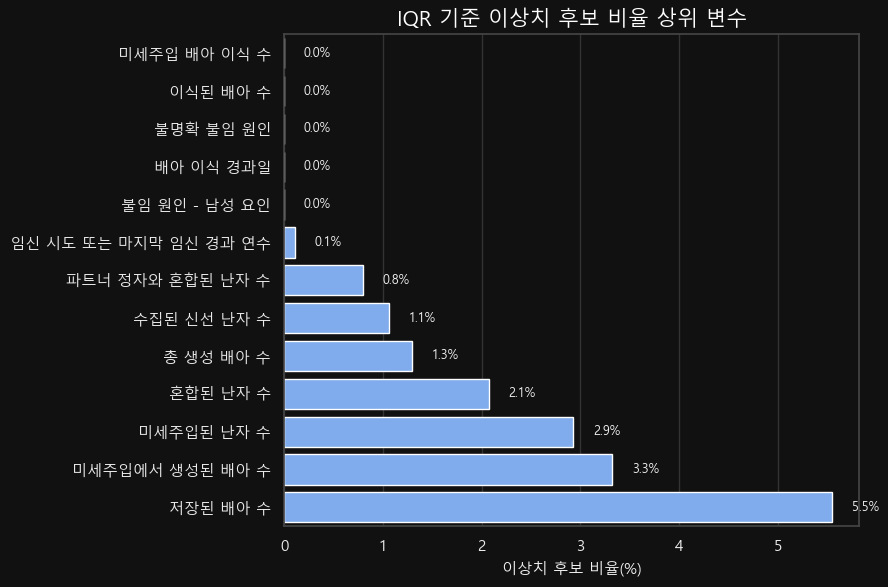

In [49]:
# IQR 기준 이상치 후보 계산 및 시각화
numeric_cols_raw = train.select_dtypes(include=[np.number]).columns.drop(TARGET, errors="ignore")

outlier_rows = []

for col in numeric_cols_raw:
    s = train[col].dropna()

    if len(s) == 0:
        continue

    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1

    if iqr == 0:
        continue

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (train[col] < lower) | (train[col] > upper)

    outlier_rows.append({
        "column": col,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_rate": outlier_mask.mean(),
        "outlier_rate_percent": outlier_mask.mean() * 100,
        "lower_bound": lower,
        "upper_bound": upper,
        "min": s.min(),
        "max": s.max(),
    })

outlier_df = (
    pd.DataFrame(outlier_rows)
    .sort_values("outlier_rate_percent", ascending=False)
)

display(outlier_df.head(30))

plot_outlier = outlier_df.head(15).sort_values("outlier_rate_percent")

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=plot_outlier,
    x="outlier_rate_percent",
    y="column",
    color=main_color
)

ax.set_title("IQR 기준 이상치 후보 비율 상위 변수")
ax.set_xlabel("이상치 후보 비율(%)")
ax.set_ylabel("")

for i, value in enumerate(plot_outlier["outlier_rate_percent"]):
    ax.text(value + 0.2, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### 01-7. 결과 해석

수치형 변수에 대해 IQR 기준 이상치 후보를 확인한 결과, 이상치 후보는 주로 배아·난자 수량 관련 변수에서 나타났다.

가장 높은 이상치 후보 비율을 보인 변수는 `저장된 배아 수`로, 약 5.5%의 행이 IQR 기준 상한값을 초과하였다.  
그 외에도 `미세주입에서 생성된 배아 수`, `미세주입된 난자 수`, `혼합된 난자 수`, `총 생성 배아 수`, `수집된 신선 난자 수` 등 난자 및 배아 수량 관련 변수에서 일부 이상치 후보가 확인되었다.

이 변수들의 최댓값은 대부분 51까지 나타나며, IQR 기준으로는 극단값으로 분류될 수 있다.  
다만 난임 시술 데이터에서 난자 또는 배아 수가 많은 경우는 실제 임상 기록일 수 있으므로, 이를 단순 오류값으로 보고 제거하는 것은 적절하지 않다.

또한 `이식된 배아 수`, `미세주입 배아 이식 수`, `배아 이식 경과일` 등은 IQR 기준 이상치 후보가 거의 없거나 0건으로 나타났다.  
이는 해당 변수들이 비교적 제한된 범위 안에서 기록되어 있음을 의미한다.

따라서 본 프로젝트에서는 이상치 후보를 즉시 제거하지 않고, 다음과 같은 방식으로 활용하는 것이 적절하다.

- 난자·배아 수량 변수는 원본 값을 유지한다.
- 극단값이 존재하는 변수는 구간화 변수를 함께 사용한다.
- 필요 시 상위 구간 여부를 나타내는 flag 변수를 생성한다.
- 트리 기반 모델은 이상치에 비교적 강하므로, 우선 원본 값을 유지하고 모델 성능을 확인한다.
- 이후 Feature Importance와 OOF ROC-AUC를 기준으로 clipping 또는 pruning 여부를 판단한다.

결론적으로, 현재 확인된 이상치 후보는 대부분 실제 시술 과정에서 발생 가능한 수량값으로 판단되며, 일괄 삭제보다는 구간화 및 모델 검증을 통해 처리하는 것이 적절하다.

### 01-8. 수치형 변수 간 상관관계 확인

수치형 변수들이 `임신 성공 여부`와 어떤 방향의 관계를 가지는지 확인한다.  
또한 변수들끼리 상관관계가 지나치게 높은 경우, 이후 모델링 단계에서 중복 정보 또는 noise pruning 후보로 검토할 수 있다.

In [50]:
# 수치형 변수와 target 간 상관관계 확인
TARGET = "임신 성공 여부"

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != TARGET]

corr_with_target = (
    train[numeric_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .reset_index()
)

corr_with_target.columns = ["feature", "corr_with_target"]
corr_with_target["abs_corr"] = corr_with_target["corr_with_target"].abs()

display(corr_with_target.head(30))

,feature,corr_with_target,abs_corr
0,이식된 배아 수,0.157487,0.157487
1,배아 이식 경과일,0.148590,0.148590
2,총 생성 배아 수,0.146116,0.146116
3,단일 배아 이식 여부,0.132635,0.132635
4,혼합된 난자 수,0.116136,0.116136
5,파트너 정자와 혼합된 난자 수,0.104902,0.104902
6,미세주입에서 생성된 배아 수,0.090275,0.090275
7,수집된 신선 난자 수,0.083023,0.083023
8,미세주입 배아 이식 수,0.074351,0.074351
9,미세주입된 난자 수,0.070117,0.070117


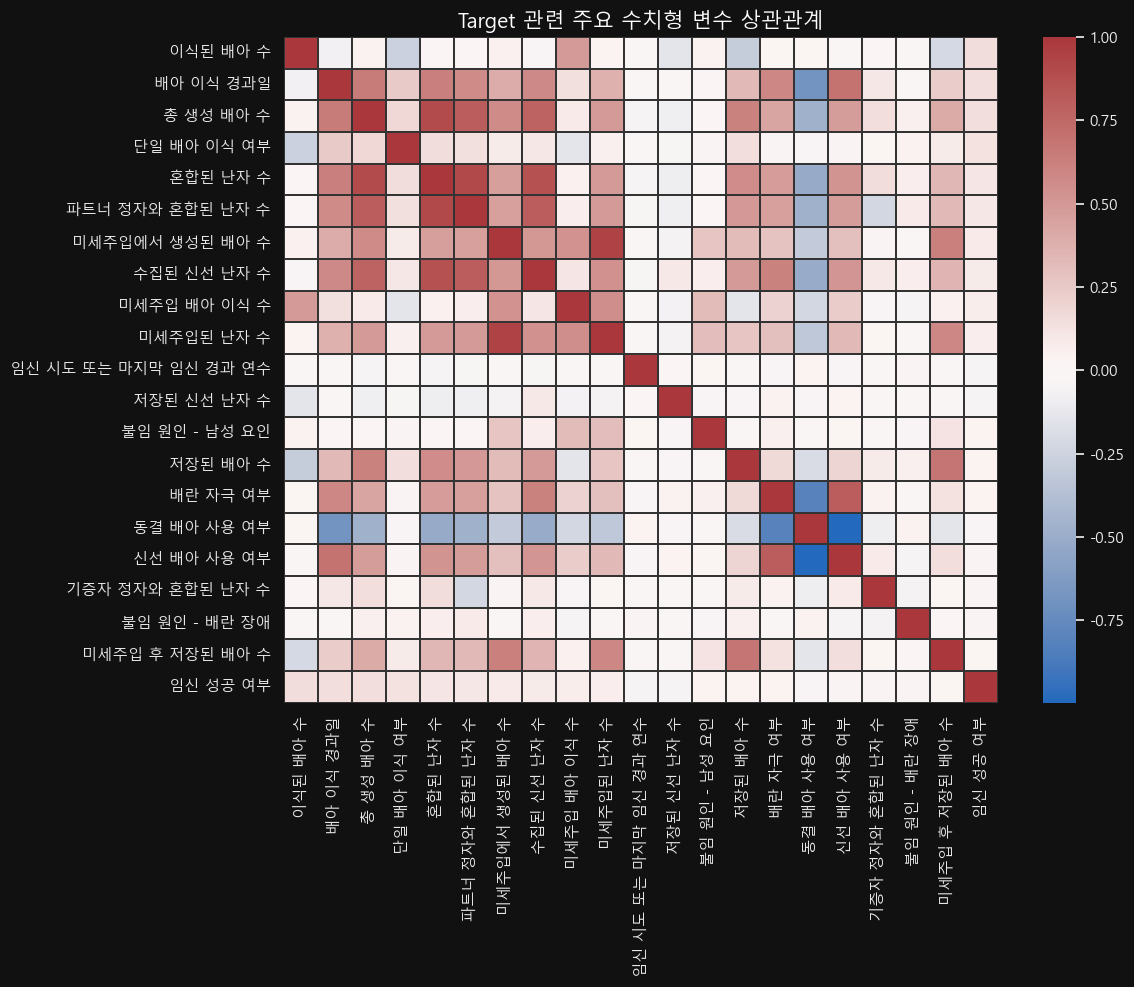

In [51]:
# target과 상관관계가 높은 변수 중심 heatmap
top_corr_features = corr_with_target.head(20)["feature"].tolist()
corr_matrix = train[top_corr_features + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    linecolor="#333333"
)

plt.title("Target 관련 주요 수치형 변수 상관관계")
plt.tight_layout()
plt.show()

In [52]:
# 변수 간 상관관계가 높은 조합 확인
feature_corr = train[top_corr_features].corr(numeric_only=True).abs()

high_corr_pairs = []

for i, col1 in enumerate(feature_corr.columns):
    for col2 in feature_corr.columns[i + 1:]:
        corr_value = feature_corr.loc[col1, col2]
        if corr_value >= 0.8:
            high_corr_pairs.append({
                "feature_1": col1,
                "feature_2": col2,
                "abs_corr": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) > 0:
    high_corr_df = high_corr_df.sort_values("abs_corr", ascending=False)

display(high_corr_df.head(30))

,feature_1,feature_2,abs_corr
8,동결 배아 사용 여부,신선 배아 사용 여부,0.996911
5,미세주입에서 생성된 배아 수,미세주입된 난자 수,0.939846
2,혼합된 난자 수,파트너 정자와 혼합된 난자 수,0.913231
0,총 생성 배아 수,혼합된 난자 수,0.891841
3,혼합된 난자 수,수집된 신선 난자 수,0.872449
7,배란 자극 여부,신선 배아 사용 여부,0.811952
6,배란 자극 여부,동결 배아 사용 여부,0.810742
1,총 생성 배아 수,파트너 정자와 혼합된 난자 수,0.810535
4,파트너 정자와 혼합된 난자 수,수집된 신선 난자 수,0.809544


#### 01-8. 결과 해석

- `임신 성공 여부`와 가장 상관관계가 높은 수치형 변수는 `이식된 배아 수`, `배아 이식 경과일`, `총 생성 배아 수`, `단일 배아 이식 여부`, `혼합된 난자 수`였다.
- 상위 변수들이 대부분 난자·배아 생성·이식 과정과 관련되어 있어, 임신 성공 여부는 단순 인구통계 변수보다 실제 시술 진행 결과와 더 직접적으로 연결되어 있음을 확인할 수 있다.
- 다만 가장 높은 상관계수도 약 0.16 수준이므로, 단일 변수만으로는 임신 성공 여부를 강하게 설명하기 어렵다. 따라서 모델링 단계에서는 변수 간 조합, 구간화, 결측 flag, 비율 변수 등을 함께 활용할 필요가 있다.
- `임신 시도 또는 마지막 임신 경과 연수`는 음의 상관관계를 보였으며, 기간이 길수록 임신 성공률이 낮아지는 방향성을 보인다.
- `동결 배아 사용 여부`와 `신선 배아 사용 여부`는 상관계수가 약 0.997로 매우 높아 사실상 중복 정보에 가깝다. 이후 Feature Importance 또는 OOF 성능 비교를 통해 하나만 남기거나 조합 변수로 재구성할 수 있다.
- `미세주입된 난자 수`와 `미세주입에서 생성된 배아 수`, `혼합된 난자 수`와 `파트너 정자와 혼합된 난자 수`도 높은 상관관계를 보여 중복 또는 파생 비율 변수 후보로 판단된다.
- 초기 모델에서는 변수 제거를 바로 수행하지 않고, 이후 모델링 결과와 Feature Importance를 기준으로 noise pruning 여부를 결정한다.

### 01-9. EDA 종합 정리 및 전처리 방향 제시

EDA를 통해 확인한 핵심 내용과 이후 전처리 방향은 다음과 같다.

1. 데이터 구조
- train 데이터에는 target인 `임신 성공 여부`가 포함되어 있고, test 데이터에는 target이 없다.
- train과 test의 컬럼 차이는 target 컬럼 하나뿐이며, 기본 데이터 구조는 정상적이다.
- 최종 목표는 test 데이터의 `임신 성공 여부` 확률을 예측하는 것이다.

2. 타깃 분포
- 임신 실패(0)는 약 74.2%, 임신 성공(1)은 약 25.8%로 나타났다.
- 성공 클래스가 상대적으로 적은 불균형 이진 분류 문제이다.
- 따라서 Accuracy보다 ROC-AUC를 핵심 평가 지표로 사용하고, LogLoss, Recall, F1-score를 보조 지표로 함께 확인한다.

3. 결측 패턴
- 일부 변수는 결측률이 90% 이상으로 매우 높게 나타났다.
- DI 시술에서는 배아·난자·이식 관련 변수의 결측률이 100%에 가깝게 나타났다.
- 이는 단순 누락이 아니라 시술 프로세스 차이에 따른 구조적 결측으로 해석할 수 있다.
- 따라서 결측값은 일괄 삭제하거나 평균값으로 대체하기보다, 결측 여부 자체를 feature로 활용할 필요가 있다.

4. 주요 범주형 변수
- `시술 유형`에서는 IVF가 DI보다 성공률이 높게 나타났다.
- `시술 당시 나이`는 성공률과 뚜렷한 관련이 있으며, 나이가 증가할수록 전반적으로 성공률이 낮아졌다.
- `특정 시술 유형`에서는 BLASTOCYST가 포함된 유형의 성공률이 상대적으로 높았다.
- `배아 생성 주요 이유`, `난자 출처`, `정자 출처`, `신선/동결 배아 사용 여부`도 성공률 차이를 보였다.
- 범주형 변수 간 조합이 의미를 가질 가능성이 있어, 이후 조합 변수를 생성한다.

5. 나이·난자·배아 구간 패턴
- 나이에서는 38세 전후로 성공률 하락 폭이 커지는 패턴이 확인되었다.
- 40세 이상, 43세 이상 구간에서도 추가적인 성공률 하락이 나타났다.
- 난자 수는 6개 이상 또는 11개 이상 구간에서 성공률이 높아지는 경향을 보였다.
- 총 생성 배아 수는 3개 이상부터 성공률이 상승하는 경향을 보였다.
- 이식된 배아 수는 단순히 많을수록 좋은 것이 아니라, 1-2개 구간에서 성공률이 높게 나타났다.
- 저장된 배아 수는 일정 수준 이후 성공률이 더 이상 증가하지 않는 패턴을 보였다.
- 따라서 수량형 변수는 원본값뿐 아니라 구간화 변수를 함께 활용한다.

6. 임상 지식 기반 결측 유추
- `해동된 배아 수 >= 1`인 경우 FER 관련 시술 가능성이 있다.
- `미세주입된 난자 수 >= 1`인 경우 ICSI 관련 시술 가능성이 있다.
- `배란 자극 여부 == 0`인 경우 자연주기 또는 비자극 방식 가능성이 있다.
- 단, 이러한 유추는 원본 값을 직접 대체하기보다 flag 변수로 먼저 활용하는 것이 안전하다.

7. 이상치 후보
- IQR 기준 이상치 후보는 주로 난자 수, 배아 수, 혼합 난자 수 등 수량형 변수에서 나타났다.
- 최대값 51처럼 큰 값이 존재하지만, 의료 시술 과정에서 발생 가능한 실제 기록일 수 있다.
- 따라서 이상치 후보를 일괄 삭제하지 않고, 구간화 또는 clipping 여부를 모델 성능 기준으로 판단한다.

8. 수치형 변수 간 상관관계
- `이식된 배아 수`, `배아 이식 경과일`, `총 생성 배아 수`, `단일 배아 이식 여부`, `혼합된 난자 수`가 target과 상대적으로 높은 상관관계를 보였다.
- 다만 가장 높은 상관계수도 약 0.16 수준으로, 단일 변수만으로는 임신 성공 여부를 강하게 설명하기 어렵다.
- `동결 배아 사용 여부`와 `신선 배아 사용 여부`처럼 서로 매우 높은 상관관계를 가진 변수들이 존재한다.
- 이러한 변수들은 이후 Feature Importance와 OOF 성능을 기준으로 noise pruning 여부를 검토한다.

9. 전처리 및 Feature Engineering 방향
- train/test를 동일한 기준으로 처리하기 위해 두 데이터를 합친 뒤 feature를 생성한다.
- target과 ID는 별도로 보존한다.
- 구조적 결측 가능성이 있는 변수는 missing flag를 생성한다.
- 나이는 순서형 변수로 변환하고, 38세 이상·40세 이상·43세 이상 flag를 생성한다.
- 난자 수, 배아 수, 이식 배아 수는 성공률 패턴을 반영하여 구간화한다.
- FER, ICSI, 자연주기 가능성을 나타내는 임상 지식 기반 flag를 생성한다.
- `나이 x 난자 출처`, `시술 유형 x 특정 시술 유형`, `배아 생성 주요 이유 x 특정 시술 유형` 등 조합 변수를 생성한다.
- 초기에는 후보 변수를 넓게 사용하고, 모델링 이후 중요도가 낮은 변수는 성능 검증을 통해 제거한다.

10. 모델링 방향
- 범주형 변수가 많고 결측 자체가 의미를 가질 수 있으므로 CatBoost를 주요 후보 모델로 사용한다.
- LightGBM, XGBoost도 함께 비교하여 트리 기반 모델 간 성능 차이를 확인한다.
- K-Fold OOF 검증을 통해 모델의 일반화 성능을 안정적으로 평가한다.
- 최종 단계에서는 단일 모델보다 여러 모델의 예측값을 조합하는 ensemble을 검토한다.

## 02. 데이터 전처리 및 Feature Engineering

EDA 결과를 바탕으로 모델 입력에 사용할 변수를 생성한다.  
본 프로젝트에서는 결측값을 단순히 삭제하거나 평균값으로 대체하지 않고, 시술 프로세스의 차이를 반영하는 신호로 활용한다.

기존 기본 전처리에서 달라지는 점은 다음과 같다.

1. 결측값을 일괄 대체하지 않는다.
- DI 시술처럼 특정 과정이 존재하지 않아 발생하는 구조적 결측이 있으므로, 결측 여부를 별도 flag로 생성한다.

2. train/test를 합쳐 동일한 기준으로 feature를 생성한다.
- train과 test에 서로 다른 기준이 적용되지 않도록, target을 분리한 뒤 전체 데이터를 합쳐 전처리한다.

3. 수량형 변수는 원본값과 구간화 변수를 함께 사용한다.
- 난자 수, 배아 수, 이식 배아 수는 단순 선형 관계가 아니라 구간별 성공률 차이가 나타났기 때문이다.

4. 임상 지식 기반 유추 feature를 생성한다.
- 해동된 배아 수, 미세주입된 난자 수, 배란 자극 여부 등을 활용해 FER, ICSI, 자연주기 가능성을 flag로 만든다.

5. 모델별 전처리 전략을 분리한다.
- CatBoost는 범주형 변수와 결측값 처리에 강점이 있으므로 주요 모델로 사용한다.
- LightGBM, XGBoost, 선형 모델은 필요에 따라 인코딩·결측 대체 방식을 별도로 적용한다.

### 02-1. Target 분리 및 train/test 통합

전처리 과정에서 target 정보가 test 데이터에 섞이지 않도록 `임신 성공 여부`를 먼저 분리한다.  
이후 train과 test를 합쳐 동일한 기준으로 파생변수를 생성한다.

기본 전처리 방향은 다음과 같다.

- 원본 데이터는 보존하고, 전처리용 복사본을 생성한다.
- ID 컬럼은 모델 학습에는 사용하지 않고 제출 파일 생성 시에만 사용한다.
- target 컬럼인 `임신 성공 여부`는 train 데이터에서만 분리한다.
- 범주형 결측은 `Unknown` 또는 `missing` 범주로 처리한다.
- 수치형 결측은 모델에 따라 NaN 유지 또는 중앙값 대체를 적용한다.
- 구조적 결측은 별도의 missing flag 변수로 생성한다.
- EDA에서 확인한 나이, 난자, 배아 관련 구간화 변수를 생성한다.

In [23]:
# 원본 데이터 보존 및 전처리용 데이터 생성
train_raw = train.copy()
test_raw = test.copy()

y = train_raw[TARGET].astype(int)

train_base = train_raw.drop(columns=[TARGET]).copy()
test_base = test_raw.copy()

print("train_raw:", train_raw.shape)
print("test_raw:", test_raw.shape)
print("train_base:", train_base.shape)
print("test_base:", test_base.shape)
print("y:", y.shape)

train_raw: (256351, 69)
test_raw: (90067, 68)
train_base: (256351, 68)
test_base: (90067, 68)
y: (256351,)


In [24]:
# train/test를 함께 결합하여 동일한 전처리 적용
all_data = pd.concat(
    [train_base, test_base],
    axis=0,
    ignore_index=True
)

print("all_data:", all_data.shape)
print("train rows:", len(train_base))
print("test rows:", len(test_base))

all_data: (346418, 68)
train rows: 256351
test rows: 90067


#### 02-1. 처리 방식 설명

전처리를 시작하기 전에 원본 train/test 데이터를 복사하여 보존하였다.  
이후 모든 전처리와 파생변수 생성은 복사본을 기준으로 수행한다.

train 데이터에서는 target 컬럼인 `임신 성공 여부`를 분리하여 `y`로 저장하였다.  
모델 학습에는 target을 제외한 feature만 사용하며, ID 컬럼은 최종 제출 파일 생성 시에만 활용한다.

또한 train과 test에 동일한 전처리 규칙을 적용하기 위해 두 데이터를 `all_data`로 결합하였다.  
이 방식은 train/test 간 컬럼 불일치나 파생변수 생성 방식 차이를 방지하는 데 도움이 된다.

단, target 정보를 사용하는 Target Encoding과 같은 전처리는 반드시 train 내부 fold에서만 계산해야 하므로, 이후 별도 단계에서 처리한다.

### 02-2. 임상 지식 기반 결측 유추 Feature 생성

EDA에서 확인한 내용을 바탕으로, 시술 프로세스상 의미가 있는 조건을 flag 변수로 생성한다.

이 단계에서는 원본 결측값이나 범주값을 직접 대체하지 않고, 도메인 지식 기반 유추 결과를 별도의 feature로 추가한다.  
이는 잘못된 대체로 인한 정보 왜곡을 줄이면서도, 모델이 시술 프로세스 신호를 학습할 수 있도록 하기 위함이다.

In [26]:
# 임상 지식 기반 유추 flag 생성
def to_numeric_safe(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(np.nan, index=df.index)


all_data["fer_inferred_flag"] = (
    to_numeric_safe(all_data, "해동된 배아 수").fillna(0) >= 1
).astype(int)

all_data["icsi_inferred_flag"] = (
    to_numeric_safe(all_data, "미세주입된 난자 수").fillna(0) >= 1
).astype(int)

all_data["natural_cycle_inferred_flag"] = (
    to_numeric_safe(all_data, "배란 자극 여부").fillna(-1) == 0
).astype(int)

all_data["unknown_proc_with_thawed_embryo_flag"] = (
    all_data["특정 시술 유형"].astype("string").fillna("Unknown").isin(["Unknown", "알 수 없음"])
    & (to_numeric_safe(all_data, "해동된 배아 수").fillna(0) >= 1)
).astype(int)

all_data["unknown_proc_with_icsi_oocyte_flag"] = (
    all_data["특정 시술 유형"].astype("string").fillna("Unknown").isin(["Unknown", "알 수 없음"])
    & (to_numeric_safe(all_data, "미세주입된 난자 수").fillna(0) >= 1)
).astype(int)

inferred_cols = [
    "fer_inferred_flag",
    "icsi_inferred_flag",
    "natural_cycle_inferred_flag",
    "unknown_proc_with_thawed_embryo_flag",
    "unknown_proc_with_icsi_oocyte_flag",
]

display(all_data[inferred_cols].sum().to_frame("count"))

,count
fer_inferred_flag,54345
icsi_inferred_flag,165653
natural_cycle_inferred_flag,78942
unknown_proc_with_thawed_embryo_flag,36131
unknown_proc_with_icsi_oocyte_flag,109


In [27]:
# train 영역 기준 유추 flag별 임신 성공률 확인
train_inferred = all_data.iloc[:len(train_base)].copy()
train_inferred[TARGET] = y.values

for col in inferred_cols:
    result = (
        train_inferred.groupby(col)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"mean": "success_rate"})
        .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
    )

    print("\n" + "=" * 80)
    print(col)
    display(result)


fer_inferred_flag


,count,success_rate,success_rate_percent
fer_inferred_flag,,,
0,215966,0.263930,26.393043
1,40385,0.228501,22.850068



icsi_inferred_flag


,count,success_rate,success_rate_percent
icsi_inferred_flag,,,
0,133960,0.245021,24.502090
1,122391,0.272937,27.293674



natural_cycle_inferred_flag


,count,success_rate,success_rate_percent
natural_cycle_inferred_flag,,,
0,197720,0.266265,26.626543
1,58631,0.231652,23.165220



unknown_proc_with_thawed_embryo_flag


,count,success_rate,success_rate_percent
unknown_proc_with_thawed_embryo_flag,,,
0,229427,0.260832,26.083242
1,26924,0.237186,23.718615



unknown_proc_with_icsi_oocyte_flag


,count,success_rate,success_rate_percent
unknown_proc_with_icsi_oocyte_flag,,,
0,256277,0.258373,25.837278
1,74,0.175676,17.567568


#### 02-2. 결과 해석

임상 지식 기반 유추 flag 변수를 생성하고, train 데이터 기준으로 각 flag별 임신 성공률을 확인하였다.

먼저 `fer_inferred_flag`는 전체 all_data 기준 54,345건 생성되었으며, train 기준으로는 40,385건이 해당된다.  
train 데이터에서 `fer_inferred_flag=1`인 그룹의 임신 성공률은 약 22.9%로, flag가 0인 그룹의 약 26.4%보다 낮게 나타났다.  
이는 해동된 배아가 존재하는 FER 관련 주기가 신선 배아 중심 주기와 다른 성공률 패턴을 가질 수 있음을 의미한다.

`icsi_inferred_flag`는 전체 all_data 기준 165,653건으로 가장 많이 생성되었으며, train 기준으로는 122,391건이 해당된다.  
`icsi_inferred_flag=1` 그룹의 성공률은 약 27.3%로, flag가 0인 그룹의 약 24.5%보다 높게 나타났다.  
이는 미세주입 과정이 수행된 경우가 임신 성공 여부와 관련된 유의미한 신호일 수 있음을 보여준다.

`natural_cycle_inferred_flag`는 전체 all_data 기준 78,942건 생성되었으며, train 기준으로는 58,631건이 해당된다.  
해당 flag가 1인 그룹의 성공률은 약 23.2%로, flag가 0인 그룹의 약 26.6%보다 낮게 나타났다.  
이는 배란 자극이 없는 자연주기 또는 비자극 방식이 별도의 시술 특성을 가지며, 모델이 구분해야 할 정보일 수 있음을 시사한다.

`unknown_proc_with_thawed_embryo_flag`는 train 기준 26,924건으로 표본 수가 충분하며, 성공률은 약 23.7%로 나타났다.  
이는 특정 시술 유형이 Unknown으로 기록되었더라도 해동된 배아 수가 존재하는 경우, 별도의 FER 관련 신호로 활용할 수 있음을 의미한다.

반면 `unknown_proc_with_icsi_oocyte_flag`는 train 기준 74건으로 표본 수가 매우 작다.  
성공률은 약 17.6%로 낮게 나타났지만, 표본 수가 적기 때문에 안정적인 일반화 신호로 보기에는 한계가 있다.  
따라서 이 변수는 모델에 넣더라도 중요도가 낮을 수 있으며, 추후 Feature Importance를 통해 제거 여부를 검토한다.

종합하면, 임상 지식 기반 유추 flag 중 우선적으로 활용할 후보는 다음과 같다.

- `fer_inferred_flag`
- `icsi_inferred_flag`
- `natural_cycle_inferred_flag`
- `unknown_proc_with_thawed_embryo_flag`

이 변수들은 원본 값을 직접 대체하지 않고, 시술 프로세스의 간접 신호를 모델이 학습할 수 있도록 추가한 feature이다.  

### 02-3. 구조적 결측 Flag 생성

EDA에서 DI와 IVF는 시술 프로세스가 다르며, 특히 DI에서는 배아·난자·이식 관련 변수가 구조적으로 결측되는 패턴을 확인하였다.

따라서 결측값을 단순히 대체하기 전에, 결측 여부 자체를 feature로 생성한다.  
이는 모델이 “값이 없음(NaN)”을 단순 누락이 아니라 “해당 시술 과정이 수행되지 않았을 가능성”으로 학습할 수 있도록 하기 위함이다.

In [28]:
# 배아·난자·이식 관련 구조적 결측 flag 생성
process_cols = [
    "총 생성 배아 수",
    "미세주입된 난자 수",
    "미세주입에서 생성된 배아 수",
    "이식된 배아 수",
    "미세주입 배아 이식 수",
    "저장된 배아 수",
    "미세주입 후 저장된 배아 수",
    "해동된 배아 수",
    "해동 난자 수",
    "수집된 신선 난자 수",
    "저장된 신선 난자 수",
    "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수",
    "기증자 정자와 혼합된 난자 수",
    "난자 채취 경과일",
    "난자 해동 경과일",
    "난자 혼합 경과일",
    "배아 이식 경과일",
    "배아 해동 경과일",
]

process_cols = [col for col in process_cols if col in all_data.columns]

for col in process_cols:
    all_data[f"{col}_missing_flag"] = all_data[col].isna().astype(int)

all_data["process_missing_count"] = all_data[process_cols].isna().sum(axis=1)
all_data["process_missing_rate"] = all_data[process_cols].isna().mean(axis=1)

print("구조적 결측 대상 변수 수:", len(process_cols))
print("생성된 missing flag 수:", len(process_cols))
display(all_data[["process_missing_count", "process_missing_rate"]].describe())

구조적 결측 대상 변수 수: 19
생성된 missing flag 수: 19


,process_missing_count,process_missing_rate
count,346418.000000,346418.000000
mean,2.781870,0.146414
std,2.629279,0.138383
min,0.000000,0.000000
25%,2.000000,0.105263
50%,2.000000,0.105263
75%,3.000000,0.157895
max,19.000000,1.000000


,process_missing_count,count,success_rate,success_rate_percent
0,1,469,0.208955,20.895522
1,2,166644,0.314611,31.461079
2,3,71314,0.178212,17.821185
3,4,11633,0.015645,1.564515
4,19,6291,0.128914,12.891432


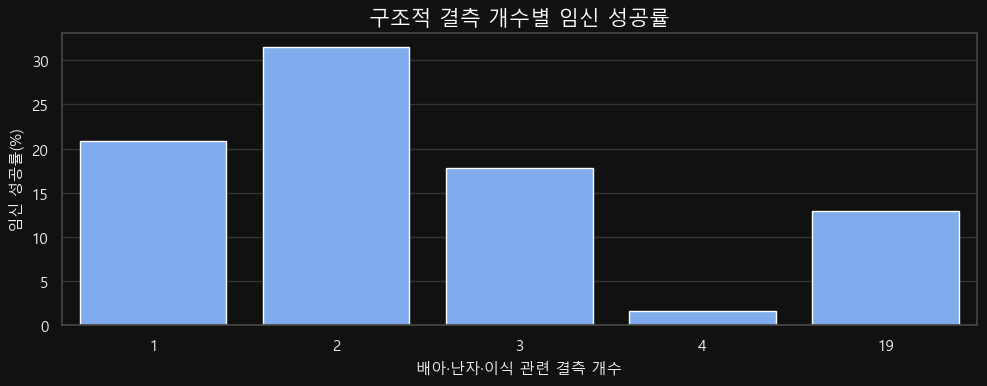

In [29]:
# train 영역 기준 구조적 결측 개수별 성공률 확인
train_missing = all_data.iloc[:len(train_base)].copy()
train_missing[TARGET] = y.values

missing_count_success = (
    train_missing.groupby("process_missing_count")[TARGET]
    .agg(["count", "mean"])
    .rename(columns={"mean": "success_rate"})
    .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
    .reset_index()
)

display(missing_count_success.head(30))

plt.figure(figsize=(10, 4))
plot_missing = missing_count_success[missing_count_success["count"] >= 100].copy()

ax = sns.barplot(
    data=plot_missing,
    x="process_missing_count",
    y="success_rate_percent",
    color=main_color
)

ax.set_title("구조적 결측 개수별 임신 성공률")
ax.set_xlabel("배아·난자·이식 관련 결측 개수")
ax.set_ylabel("임신 성공률(%)")

plt.tight_layout()
plt.show()

In [30]:
# 시술 유형별 구조적 결측 개수 확인
if "시술 유형" in train_missing.columns:
    missing_by_treatment = (
        train_missing.groupby("시술 유형")["process_missing_count"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("mean", ascending=False)
    )

    display(missing_by_treatment)

,count,mean,median,min,max
시술 유형,,,,,
DI,6291,19.000000,19.0,19,19
IVF,250060,2.376354,2.0,1,4


#### 02-3. 결과 해석 및 결론

배아·난자·이식 관련 변수 19개를 구조적 결측 후보 변수로 정의하고, 각 변수에 대해 missing flag를 생성하였다.  
또한 각 행에서 해당 변수들이 몇 개 결측인지 나타내는 `process_missing_count`와 결측 비율인 `process_missing_rate`를 생성하였다.

전체 all_data 기준 `process_missing_count`의 평균은 약 2.78개이며, 중앙값은 2개로 나타났다.  
즉, 대부분의 행은 배아·난자·이식 관련 변수 중 일부만 결측을 가지지만, 최대 19개까지 결측이 발생하는 행도 존재한다.

train 데이터 기준으로 `process_missing_count`별 성공률을 확인한 결과, 결측 개수에 따라 성공률이 크게 달라졌다.  
결측 개수가 2개인 그룹은 약 31.5%의 성공률을 보인 반면, 결측 개수가 3개인 그룹은 약 17.8%, 4개인 그룹은 약 1.6%로 크게 낮아졌다.  
따라서 결측 개수 자체가 임신 성공 여부와 관련된 중요한 신호일 가능성이 있다.

특히 `process_missing_count`가 19개인 그룹은 6,291건이며, 성공률은 약 12.9%로 나타났다.  
이 6,291건은 시술 유형이 DI인 행과 정확히 일치한다.

시술 유형별로 확인한 결과, DI는 `process_missing_count`의 평균, 중앙값, 최소값, 최대값이 모두 19로 나타났다.  
즉, DI 시술에서는 배아·난자·이식 관련 19개 변수가 모두 결측이며, 이는 단순 누락이 아니라 DI 시술 프로세스상 해당 과정이 존재하지 않기 때문에 발생한 구조적 결측으로 해석할 수 있다.

반면 IVF는 `process_missing_count`가 평균 약 2.38개, 중앙값 2개이며, 최소 1개에서 최대 4개까지 분포한다.  
이는 IVF에서도 일부 경과일 또는 해동 관련 변수의 결측이 존재하지만, DI처럼 모든 배아·난자·이식 변수가 결측되는 구조는 아님을 보여준다.

종합하면, `process_missing_count`, `process_missing_rate`, 그리고 개별 missing flag 변수들은 시술 유형과 시술 진행 과정을 반영하는 중요한 파생변수로 판단된다.

이후 모델링에서는 다음 변수를 활용한다.

- 개별 배아·난자·이식 관련 missing flag
- `process_missing_count`
- `process_missing_rate`
- `process_missing_count == 19` 여부

이 변수들은 모델이 단순 수치값뿐 아니라, 시술 프로세스의 존재 여부와 구조적 결측 패턴을 함께 학습하도록 돕는다.

### 02-4. 구간화 변수 생성

EDA에서 나이, 난자 수, 배아 수는 임신 성공률과 관련된 구간 패턴을 보였다.

따라서 원본 수치 또는 범주형 변수를 그대로 사용하는 것과 함께, 임상적 의미를 반영한 구간화 변수를 추가로 생성한다.

구간화 변수는 모델이 특정 임계점이나 plateau 패턴을 더 쉽게 학습하도록 돕는다.

In [32]:
# 나이, 난자 수, 배아 수 구간화 함수 정의
age_ord_map = {
    "만18-34세": 0,
    "만35-37세": 1,
    "만38-39세": 2,
    "만40-42세": 3,
    "만43-44세": 4,
    "만45-50세": 5,
    "알 수 없음": np.nan,
}

def make_oocyte_bin(s):
    return pd.cut(
        s,
        bins=[-0.1, 0, 5, 10, np.inf],
        labels=["0개", "1-5개", "6-10개", "11개 이상"],
        include_lowest=True
    )

def make_embryo_bin(s):
    return pd.cut(
        s,
        bins=[-0.1, 0, 2, 5, np.inf],
        labels=["0개", "1-2개", "3-5개", "6개 이상"],
        include_lowest=True
    )

def make_transfer_embryo_bin(s):
    return pd.cut(
        s,
        bins=[-0.1, 0, 2, np.inf],
        labels=["0개", "1-2개", "3개 이상"],
        include_lowest=True
    )

In [33]:
# 나이 관련 구간화 및 threshold 변수 생성
all_data["age_ord"] = all_data["시술 당시 나이"].map(age_ord_map)
all_data["age_38plus_flag"] = (all_data["age_ord"] >= 2).astype(int)
all_data["age_40plus_flag"] = (all_data["age_ord"] >= 3).astype(int)
all_data["age_43plus_flag"] = (all_data["age_ord"] >= 4).astype(int)
all_data["age_unknown_flag"] = all_data["age_ord"].isna().astype(int)

age_feature_cols = [
    "age_ord",
    "age_38plus_flag",
    "age_40plus_flag",
    "age_43plus_flag",
    "age_unknown_flag",
]

display(all_data[age_feature_cols].head())
display(all_data[age_feature_cols].sum(numeric_only=True).to_frame("sum"))

,age_ord,age_38plus_flag,age_40plus_flag,age_43plus_flag,age_unknown_flag
0,0.0,0,0,0,0
1,5.0,1,1,1,0
2,0.0,0,0,0,0
3,1.0,0,0,0,0
4,0.0,0,0,0,0


,sum
age_ord,448304.0
age_38plus_flag,129328.0
age_40plus_flag,76470.0
age_43plus_flag,25856.0
age_unknown_flag,445.0


In [34]:
# 난자 수 구간화 변수 생성
oocyte_bin_cols = [
    "수집된 신선 난자 수",
    "혼합된 난자 수",
    "해동 난자 수",
]

for col in oocyte_bin_cols:
    if col in all_data.columns:
        all_data[f"{col}_bin"] = make_oocyte_bin(
            pd.to_numeric(all_data[col], errors="coerce")
        ).astype("string").fillna("missing")

created_oocyte_bin_features = [f"{col}_bin" for col in oocyte_bin_cols if f"{col}_bin" in all_data.columns]

for col in created_oocyte_bin_features:
    print("\n" + "=" * 80)
    print(col)
    display(all_data[col].value_counts(dropna=False).to_frame("count"))


수집된 신선 난자 수_bin


,count
수집된 신선 난자 수_bin,
11개 이상,122273
6-10개,87678
0개,72525
1-5개,55475
missing,8467



혼합된 난자 수_bin


,count
혼합된 난자 수_bin,
6-10개,101121
11개 이상,98736
1-5개,75331
0개,62763
missing,8467



해동 난자 수_bin


,count
해동 난자 수_bin,
0개,336012
missing,8467
6-10개,981
1-5개,514
11개 이상,444


In [35]:
# 배아 수 구간화 변수 생성
embryo_bin_cols = [
    "총 생성 배아 수",
    "저장된 배아 수",
]

for col in embryo_bin_cols:
    if col in all_data.columns:
        all_data[f"{col}_bin"] = make_embryo_bin(
            pd.to_numeric(all_data[col], errors="coerce")
        ).astype("string").fillna("missing")

if "이식된 배아 수" in all_data.columns:
    all_data["이식된 배아 수_bin"] = make_transfer_embryo_bin(
        pd.to_numeric(all_data["이식된 배아 수"], errors="coerce")
    ).astype("string").fillna("missing")

created_embryo_bin_features = [
    "총 생성 배아 수_bin",
    "저장된 배아 수_bin",
    "이식된 배아 수_bin",
]

created_embryo_bin_features = [
    col for col in created_embryo_bin_features if col in all_data.columns
]

for col in created_embryo_bin_features:
    print("\n" + "=" * 80)
    print(col)
    display(all_data[col].value_counts(dropna=False).to_frame("count"))


총 생성 배아 수_bin


,count
총 생성 배아 수_bin,
6개 이상,134143
3-5개,85394
0개,71823
1-2개,46591
missing,8467



저장된 배아 수_bin


,count
저장된 배아 수_bin,
0개,225572
1-2개,54444
3-5개,38794
6개 이상,19141
missing,8467



이식된 배아 수_bin


,count
이식된 배아 수_bin,
1-2개,276587
0개,49349
3개 이상,12015
missing,8467


In [36]:
# train 영역 기준 생성된 구간화 변수별 성공률 확인
train_bins = all_data.iloc[:len(train_base)].copy()
train_bins[TARGET] = y.values

bin_feature_cols = (
    age_feature_cols
    + created_oocyte_bin_features
    + created_embryo_bin_features
)

for col in bin_feature_cols:
    result = (
        train_bins.groupby(col, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"mean": "success_rate"})
        .assign(success_rate_percent=lambda x: x["success_rate"] * 100)
        .sort_values("success_rate_percent", ascending=False)
    )

    print("\n" + "=" * 80)
    print(col)
    display(result)


age_ord


,count,success_rate,success_rate_percent
age_ord,,,
0.0,102476,0.322622,32.262188
1.0,57780,0.278401,27.840083
2.0,39247,0.217138,21.713762
5.0,6918,0.167679,16.767852
3.0,37348,0.159393,15.939274
4.0,12253,0.118012,11.801192
NaN,329,0.000000,0.000000



age_38plus_flag


,count,success_rate,success_rate_percent
age_38plus_flag,,,
0,160585,0.306050,30.604976
1,95766,0.178362,17.836184



age_40plus_flag


...

,count,success_rate,success_rate_percent
총 생성 배아 수_bin,,,
6개 이상,99324,0.342848,34.284765
3-5개,62974,0.274637,27.463715
0개,53349,0.171868,17.186826
1-2개,34413,0.142388,14.238805
missing,6291,0.128914,12.891432



저장된 배아 수_bin


,count,success_rate,success_rate_percent
저장된 배아 수_bin,,,
3-5개,28731,0.362431,36.243082
1-2개,40245,0.357759,35.775873
6개 이상,14218,0.248980,24.898017
0개,166866,0.222130,22.213033
missing,6291,0.128914,12.891432



이식된 배아 수_bin


,count,success_rate,success_rate_percent
이식된 배아 수_bin,,,
1-2개,204636,0.312218,31.221779
3개 이상,8880,0.168468,16.846847
missing,6291,0.128914,12.891432
0개,36544,0.000821,0.082093


#### 02-4. 결과 해석
EDA에서 확인한 나이, 난자 수, 배아 수의 구간 패턴을 바탕으로 구간화 파생변수를 생성하고, train 기준 성공률을 확인하였다.

먼저 나이 관련 변수에서는 성공률 차이가 매우 뚜렷하게 나타났다.  
`age_38plus_flag` 기준으로 38세 미만 그룹의 성공률은 약 30.6%, 38세 이상 그룹은 약 17.8%로 크게 낮아졌다.  
`age_40plus_flag`에서도 40세 미만은 약 28.9%, 40세 이상은 약 15.1%로 차이가 나타났으며, `age_43plus_flag` 역시 43세 이상에서 성공률이 약 13.6%로 낮게 나타났다.  
따라서 38세, 40세, 43세 기준 threshold 변수는 임신 성공률 하락 구간을 반영하는 중요한 feature로 활용할 수 있다.

난자 수 관련 변수에서는 `수집된 신선 난자 수`와 `혼합된 난자 수` 모두 6개 이상 구간부터 성공률이 높아지는 패턴이 확인되었다.  
특히 `수집된 신선 난자 수`는 11개 이상 구간에서 약 32.1%, `혼합된 난자 수`는 11개 이상 구간에서 약 33.3%로 가장 높은 성공률을 보였다.  
반면 1-5개 구간은 0개 구간보다도 낮은 성공률을 보여, 난자 수가 단순히 0보다 많다고 해서 성공률이 바로 증가하는 것은 아님을 확인할 수 있다.

`해동 난자 수`는 대부분이 0개 구간에 몰려 있으며, 1개 이상 구간의 표본 수가 상대적으로 작다.  
따라서 이 변수의 구간별 성공률은 해석에 주의가 필요하며, 단독 구간화 변수보다는 해동 여부 또는 다른 변수와의 조합으로 활용하는 것이 적절할 수 있다.

배아 수 관련 변수에서는 `총 생성 배아 수`가 3개 이상부터 성공률이 상승하고, 6개 이상 구간에서 약 34.3%로 가장 높게 나타났다.  
이는 생성된 배아 수가 일정 수준 이상 확보될 때 임신 성공 가능성이 높아질 수 있음을 의미한다.

`저장된 배아 수`는 1-2개와 3-5개 구간에서 성공률이 약 35~36%로 높게 나타났고, 6개 이상에서는 약 24.9%로 낮아졌다.  
이는 저장 배아 수가 많을수록 무조건 성공률이 높아지는 것이 아니라, 일정 수준 이후에는 효과가 둔화되거나 다른 조건과 함께 해석해야 함을 시사한다.

`이식된 배아 수`에서는 1-2개 구간의 성공률이 약 31.2%로 가장 높게 나타났다.  
반면 0개 구간은 성공률이 약 0.08%로 거의 없고, 3개 이상 구간은 약 16.8%로 낮아졌다.  
따라서 이식된 배아 수는 단순히 많을수록 좋은 변수가 아니라, 적정 이식 수가 중요한 변수로 해석된다.

또한 각 구간화 변수에서 `missing` 그룹은 약 12.9%의 성공률을 보이며, 이는 DI 시술의 구조적 결측 패턴과 연결될 가능성이 높다.  
따라서 missing을 단순 대체하지 않고 별도 범주로 유지하는 것이 적절하다.

종합하면, 다음 구간화 변수들은 모델 입력 feature로 활용할 가치가 있다.

- `age_ord`
- `age_38plus_flag`
- `age_40plus_flag`
- `age_43plus_flag`
- `수집된 신선 난자 수_bin`
- `혼합된 난자 수_bin`
- `총 생성 배아 수_bin`
- `저장된 배아 수_bin`
- `이식된 배아 수_bin`

이후 모델링 단계에서는 원본 수치형 변수와 구간화 변수를 함께 사용한 뒤, Feature Importance와 OOF ROC-AUC 등 평가지표를 기준으로 실제 기여도를 판단한다.

### 02-5. 조합 변수 및 비율 변수 생성

EDA 결과, 단일 변수뿐 아니라 변수 간 조합이 임신 성공률과 관련될 가능성이 확인되었다.

특히 나이와 난자 출처, 시술 유형과 특정 시술 유형, 배아 생성 수와 이식 수의 관계는 단독 변수보다 조합으로 해석할 때 더 의미가 클 수 있다.

따라서 주요 조합 변수와 비율 변수를 생성하여 모델이 변수 간 상호작용을 학습할 수 있도록 한다.

In [37]:
# 안전한 비율 계산 함수
def safe_ratio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce").replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)

In [38]:
# 주요 조합 변수 생성
all_data["age_x_egg_source"] = (
    all_data["시술 당시 나이"].astype("string").fillna("missing")
    + "__"
    + all_data["난자 출처"].astype("string").fillna("missing")
)

all_data["treatment_x_specific_proc"] = (
    all_data["시술 유형"].astype("string").fillna("missing")
    + "__"
    + all_data["특정 시술 유형"].astype("string").fillna("missing")
)

all_data["age_x_specific_proc"] = (
    all_data["시술 당시 나이"].astype("string").fillna("missing")
    + "__"
    + all_data["특정 시술 유형"].astype("string").fillna("missing")
)

all_data["reason_x_specific_proc"] = (
    all_data["배아 생성 주요 이유"].astype("string").fillna("missing")
    + "__"
    + all_data["특정 시술 유형"].astype("string").fillna("missing")
)

combo_cols = [
    "age_x_egg_source",
    "treatment_x_specific_proc",
    "age_x_specific_proc",
    "reason_x_specific_proc",
]

for col in combo_cols:
    print("\n" + "=" * 80)
    print(col)
    display(all_data[col].value_counts(dropna=False).head(15).to_frame("count"))


age_x_egg_source


,count
age_x_egg_source,
만18-34세__본인 제공,132004
만35-37세__본인 제공,73479
만38-39세__본인 제공,49222
만40-42세__본인 제공,44893
만43-44세__본인 제공,12620
만45-50세__기증 제공,4959
만40-42세__기증 제공,4330
만45-50세__본인 제공,4025
만18-34세__기증 제공,3899



treatment_x_specific_proc


,count
treatment_x_specific_proc,
IVF__ICSI,165605
IVF__IVF,124105
IVF__Unknown,36155
DI__IUI,8212
IVF__ICSI:ICSI,3111
IVF__ICSI / BLASTOCYST,2193
IVF__IVF / BLASTOCYST,1637
IVF__IVF:IVF,1552
IVF__ICSI:IVF,1171



age_x_specific_proc


,count
age_x_specific_proc,
만18-34세__ICSI,71034
만18-34세__IVF,47647
만35-37세__ICSI,36738
만35-37세__IVF,28440
만38-39세__ICSI,24301
만40-42세__ICSI,22810
만38-39세__IVF,19451
만40-42세__IVF,18688
만18-34세__Unknown,11680



reason_x_specific_proc


,count
reason_x_specific_proc,
현재 시술용__ICSI,156490
현재 시술용__IVF,113969
현재 시술용__Unknown,36092
missing__IUI,8212
배아 저장용__ICSI,6097
배아 저장용__IVF,3765
"기증용, 현재 시술용__ICSI",2777
난자 저장용__IVF,2619
"기증용, 현재 시술용__IVF",2194


In [39]:
# 배아·난자 관련 비율 변수 생성
all_data["transfer_per_created_embryo"] = safe_ratio(
    all_data["이식된 배아 수"],
    all_data["총 생성 배아 수"]
)

all_data["stored_per_created_embryo"] = safe_ratio(
    all_data["저장된 배아 수"],
    all_data["총 생성 배아 수"]
)

all_data["thawed_per_stored_embryo"] = safe_ratio(
    all_data["해동된 배아 수"],
    all_data["저장된 배아 수"]
)

all_data["mixed_per_fresh_oocyte"] = safe_ratio(
    all_data["혼합된 난자 수"],
    all_data["수집된 신선 난자 수"]
)

all_data["icsi_oocyte_rate"] = safe_ratio(
    all_data["미세주입된 난자 수"],
    all_data["혼합된 난자 수"]
)

ratio_cols = [
    "transfer_per_created_embryo",
    "stored_per_created_embryo",
    "thawed_per_stored_embryo",
    "mixed_per_fresh_oocyte",
    "icsi_oocyte_rate",
]

display(all_data[ratio_cols].describe())

,transfer_per_created_embryo,stored_per_created_embryo,thawed_per_stored_embryo,mixed_per_fresh_oocyte,icsi_oocyte_rate
count,266128.000000,266128.000000,112379.000000,265426.000000,275188.000000
mean,0.367617,0.179962,0.069732,0.862661,0.590923
std,0.318765,0.271368,0.671940,0.213547,0.486579
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125000,0.000000,0.000000,0.785714,0.000000
50%,0.250000,0.000000,0.000000,1.000000,1.000000
75%,0.500000,0.333333,0.000000,1.000000,1.000000
max,3.000000,7.000000,26.000000,9.000000,1.000000


In [40]:
# train 영역 기준 비율 변수와 target의 관계 확인
train_ratio = all_data.iloc[:len(train_base)].copy()
train_ratio[TARGET] = y.values

ratio_summary = []

for col in ratio_cols:
    temp = train_ratio[[col, TARGET]].copy()
    temp[f"{col}_missing_flag"] = temp[col].isna().astype(int)

    not_missing = temp[temp[col].notna()]
    missing = temp[temp[col].isna()]

    ratio_summary.append({
        "feature": col,
        "missing_count": len(missing),
        "not_missing_count": len(not_missing),
        "missing_success_rate": missing[TARGET].mean(),
        "not_missing_success_rate": not_missing[TARGET].mean(),
        "corr_with_target": temp[[col, TARGET]].corr(numeric_only=True).iloc[0, 1]
    })

ratio_summary_df = pd.DataFrame(ratio_summary)
display(ratio_summary_df)

,feature,missing_count,not_missing_count,missing_success_rate,not_missing_success_rate,corr_with_target
0,transfer_per_created_embryo,59640,196711,0.167337,0.285942,-0.092649
1,stored_per_created_embryo,59640,196711,0.167337,0.285942,0.000930
2,thawed_per_stored_embryo,173157,83194,0.218744,0.340782,0.004178
3,mixed_per_fresh_oocyte,60136,196215,0.228815,0.267401,0.071579
4,icsi_oocyte_rate,52941,203410,0.188228,0.276599,-0.013622


#### 02-5. 결과 해석

주요 조합 변수와 비율 변수를 생성하고 분포 및 target과의 관계를 확인하였다.

먼저 조합 변수에서는 `age_x_egg_source`, `treatment_x_specific_proc`, `age_x_specific_proc`, `reason_x_specific_proc`를 생성하였다.  
이 변수들은 단일 변수만으로 설명하기 어려운 상호작용을 모델이 학습할 수 있도록 하기 위한 feature이다.

`age_x_egg_source`에서는 대부분의 표본이 본인 제공 난자에 집중되어 있으며, 고령 구간에서는 기증 제공 난자 조합도 일정 수 이상 존재한다.  
이는 나이 효과가 난자 출처에 따라 달라질 수 있음을 반영하는 변수로 활용할 수 있다.

`treatment_x_specific_proc`에서는 `IVF__ICSI`, `IVF__IVF`, `IVF__Unknown`이 가장 큰 비중을 차지한다.  
DI에서는 주로 `DI__IUI` 조합이 나타난다.  
이는 시술 유형과 세부 시술 유형을 함께 고려해야 IVF/DI의 구조 차이와 세부 시술 방식의 차이를 동시에 반영할 수 있음을 보여준다.

`reason_x_specific_proc`에서는 `현재 시술용__ICSI`, `현재 시술용__IVF`, `현재 시술용__Unknown` 조합이 가장 많다.  
반면 `missing__IUI`는 DI 계열과 연결된 구조적 결측 조합으로 해석할 수 있다.  
따라서 배아 생성 주요 이유의 결측 역시 단순 누락이 아니라 시술 유형과 연결된 정보일 수 있다.

비율 변수에서는 배아와 난자 관련 수량 간의 상대적 관계를 표현하였다.  
`transfer_per_created_embryo`, `stored_per_created_embryo`, `thawed_per_stored_embryo`, `mixed_per_fresh_oocyte`, `icsi_oocyte_rate`를 생성하였다.

비율 변수의 결측 여부 자체도 의미 있는 신호로 나타났다.  
예를 들어 `transfer_per_created_embryo`와 `stored_per_created_embryo`가 결측인 그룹의 성공률은 약 16.7%, 결측이 아닌 그룹은 약 28.6%로 차이가 크다.  
이는 배아 생성 또는 이식 관련 과정이 존재하지 않는 경우 성공률 패턴이 다르다는 것을 의미한다.

`thawed_per_stored_embryo`는 결측이 아닌 그룹의 성공률이 약 34.1%로, 결측 그룹의 약 21.9%보다 높게 나타났다.  
이는 저장 및 해동 배아 관련 정보가 존재하는 경우 임신 성공률이 다르게 나타날 수 있음을 보여준다.

`mixed_per_fresh_oocyte` 역시 결측이 아닌 그룹의 성공률이 약 26.7%, 결측 그룹은 약 22.9%로 차이를 보였다.  
`icsi_oocyte_rate`는 결측이 아닌 그룹의 성공률이 약 27.7%, 결측 그룹은 약 18.8%로 나타났다.

다만 일부 비율 변수는 최댓값이 1을 초과한다.  
예를 들어 `transfer_per_created_embryo`, `stored_per_created_embryo`, `thawed_per_stored_embryo`, `mixed_per_fresh_oocyte`에서 1보다 큰 값이 존재한다.  
이는 기록 방식, 분모가 작거나 0에 가까운 경우, 또는 변수 정의 차이에서 발생할 수 있으므로 이후 전처리 단계에서 clipping 또는 이상치 flag 생성을 검토할 필요가 있다.

종합하면, 조합 변수와 비율 변수는 시술 프로세스와 변수 간 상호작용을 반영하는 중요한 feature 후보이다.  
이후 모델링에서는 다음 변수를 우선 활용한다.

- `age_x_egg_source`
- `treatment_x_specific_proc`
- `age_x_specific_proc`
- `reason_x_specific_proc`
- `transfer_per_created_embryo`
- `stored_per_created_embryo`
- `thawed_per_stored_embryo`
- `mixed_per_fresh_oocyte`
- `icsi_oocyte_rate`

또한 비율 변수의 결측 여부와 극단값 여부도 별도 flag로 생성할 수 있다.

### 02-6. 범주형/수치형 변수 정리 및 train/test 재분리

지금까지 train과 test를 결합한 `all_data`에 동일한 전처리 및 파생변수 생성을 적용하였다.

이제 모델 학습을 위해 다시 train 영역과 test 영역을 분리한다.  
또한 모델 입력에 사용할 feature에서 ID 컬럼을 제거하고, 범주형 변수와 수치형 변수를 구분한다.

In [41]:
# train/test 영역 재분리
X = all_data.iloc[:len(train_base)].copy()
X_test = all_data.iloc[len(train_base):].copy()

print("X:", X.shape)
print("X_test:", X_test.shape)
print("y:", y.shape)

X: (256351, 114)
X_test: (90067, 114)
y: (256351,)


In [43]:
# ID 컬럼 제거
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

if ID_COL in X_test.columns:
    X_test = X_test.drop(columns=[ID_COL])

print("X after ID drop:", X.shape)
print("X_test after ID drop:", X_test.shape)

X after ID drop: (256351, 113)
X_test after ID drop: (90067, 113)


In [44]:
# 범주형/수치형 변수 구분
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]

print("전체 feature 수:", X.shape[1])
print("범주형 변수 수:", len(cat_cols))
print("수치형 변수 수:", len(num_cols))

print("\n범주형 변수 예시:")
print(cat_cols[:20])

print("\n수치형 변수 예시:")
print(num_cols[:20])

전체 feature 수: 113
범주형 변수 수: 30
수치형 변수 수: 83

범주형 변수 예시:
['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이']

수치형 변수 예시:
['임신 시도 또는 마지막 임신 경과 연수', '배란 자극 여부', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인']


In [45]:
# 범주형/수치형 변수 구분
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]

print("전체 feature 수:", X.shape[1])
print("범주형 변수 수:", len(cat_cols))
print("수치형 변수 수:", len(num_cols))

print("\n범주형 변수 예시:")
print(cat_cols[:20])

print("\n수치형 변수 예시:")
print(num_cols[:20])

전체 feature 수: 113
범주형 변수 수: 30
수치형 변수 수: 83

범주형 변수 예시:
['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이']

수치형 변수 예시:
['임신 시도 또는 마지막 임신 경과 연수', '배란 자극 여부', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인']


#### 02-6. 결과 해석

전처리 및 Feature Engineering을 적용한 결과, 최종 feature 수는 113개로 구성되었다.  
기존 원본 feature 수가 67개였던 점을 고려하면, EDA 기반 파생변수를 통해 약 46개의 feature가 추가되었다.

최종 feature 중 범주형 변수는 30개, 수치형 변수는 83개로 분리되었다.  
범주형 변수에는 시술 시기 코드, 시술 당시 나이, 시술 유형, 특정 시술 유형, 배란 유도 유형, 배아 생성 주요 이유, 시술 횟수 관련 변수, 난자/정자 출처 등이 포함된다.

수치형 변수에는 배란 자극 여부, 단일 배아 이식 여부, 불임 원인 관련 이진 변수, 배아·난자 수량 변수, 경과일 변수, 그리고 새로 생성한 flag 및 비율 변수가 포함된다.

범주형 변수는 CatBoost에서 직접 처리할 수 있도록 문자열 형태로 변환하고, 결측값은 `missing` 범주로 처리하였다.  
수치형 변수는 숫자형으로 변환하되, 결측값은 우선 NaN으로 유지하였다.

이번 전처리의 핵심은 단순히 변수 개수를 늘리는 것이 아니라, EDA에서 확인한 다음 정보를 모델이 학습할 수 있도록 구조화했다는 점이다.

- 시술 유형별 구조적 결측
- 임상 지식 기반 FER/ICSI/자연주기 유추 flag
- 나이, 난자 수, 배아 수의 구간 패턴
- 나이와 난자 출처의 조합
- 시술 유형과 특정 시술 유형의 조합
- 배아·난자 관련 비율 정보

이제 모델링 단계에서는 이 feature set을 활용하여 Baseline 모델과 CatBoost 모델을 학습하고, ROC-AUC 기준으로 성능을 비교한다.

## 03. 모델링

모델링 단계에서는 Baseline 모델부터 시작해 CatBoost, LightGBM, XGBoost 등 트리 기반 모델을 비교하고, K-Fold OOF 기반으로 성능을 검증한다.


## 04. 평가

평가는 ROC-AUC를 핵심 지표로 사용한다. 보조적으로 LogLoss, Accuracy, Precision, Recall, F1-score를 함께 확인한다.


## 05. 제출 및 리더보드 확인

최종 모델 또는 앙상블 모델로 test 데이터의 임신 성공 확률을 예측하고, 제출 형식에 맞는 CSV 파일을 생성한다.
